# GlucoLens: Explainable ML for Early Prediction of Diabetes Risk (Kaggle data)

1. **Classification:** does a patient have diabetes?
2. **Regression (Ridge):** what is a patient's BMI, given their other routine measurements?

Both tasks use the Kaggle *Diabetes Prediction Dataset* (about 100,000 patients). This notebook follows exactly the same steps as our Pima notebook (`diabetes_risk.ipynb`); only the dataset is different.

| # | Rubric item | Marks | Section |
|---|---|---|---|
| 1 | Problem Understanding & Familiarization | 4 | A |
| 2 | Exploratory Data Analysis & Insights | 4 | B |
| 3 | Regression and Classification | 4 | C, D, E |
| 4 | Comparative Performance Analysis | 4 | F |
| 5 | Result Interpretation & Presentation | 4 | G, H |

## Setup
Import libraries, set one random seed for the whole notebook (so results are the same every run), and create the folder for this notebook's figures.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42  # used everywhere so results are reproducible

os.makedirs("figures/kaggle", exist_ok=True)   # kept apart from the Pima figures

# Section A: Problem Understanding *(Rubric 1)*

## A.1 Background
- **Diabetes:** blood glucose stays too high because the body makes too little **insulin** or does not respond to it.
- **Type 1:** the body makes almost no insulin (autoimmune, usually starts young). **Type 2:** the body resists insulin; linked to obesity, inactivity and age. Most cases are Type 2.
- **HbA1c:** the share of haemoglobin with glucose attached, in %. It reflects the *average* blood sugar over the last 2–3 months. About 6.5% or higher is a standard diagnostic cut-off for diabetes; 5.7–6.4% is "prediabetes".
- **Why early detection:** Type 2 can go unnoticed for years while damaging eyes, kidneys, nerves and heart. Catching it early lets lifestyle changes or treatment delay it.
- **Known risk factors:** high glucose, high BMI, older age, high blood pressure, heart disease, smoking.
- **Why explainability:** doctors must be able to see *why* a model flags a patient, to trust it, justify decisions and spot when the model is using a wrong signal.

## A.2 The two tasks

| | Classification | Regression |
|---|---|---|
| Target | `diabetes`: 1 = diabetic, 0 = not | `bmi` (kg/m²) |
| Model(s) | Logistic Regression, Decision Tree, Random Forest | Ridge Regression |
| Why this type | Target has only 2 values | Target is a continuous number |

- A classifier predicts a probability $\hat{p} = P(y=1 \mid \mathbf{x})$ and says "diabetic" if $\hat{p} \ge 0.5$ (we can change this threshold later).
- A regressor predicts a number $\hat{y} = f(\mathbf{x})$.

Here $\mathbf{x}$ = a patient's features, $y$ = the true target, $\hat{y}$ = the prediction.

**Two feature sets for classification.** In this dataset the `diabetes` label is closely tied to HbA1c and blood glucose (diabetes is *diagnosed* from these two tests). A model that sees them is partly reading the answer. So we train every classifier twice:
- **all features**, and
- **no blood test**: only age, gender, BMI, hypertension, heart disease and smoking history. This is the realistic screening question: *who should get a blood test?*

## A.3 Feature dictionary

| Feature | Unit | Meaning | Modifiable? |
|---|---|---|---|
| gender | text | Female / Male / Other | No |
| age | years | Age | No |
| hypertension | 0/1 | 1 = has high blood pressure | Partly (treatable) |
| heart_disease | 0/1 | 1 = has heart disease | Partly |
| smoking_history | text | never, former, current, not current, ever, No Info | Yes |
| bmi | kg/m² | Weight / height² | Yes |
| HbA1c_level | % | Average blood sugar over 2–3 months | Yes |
| blood_glucose_level | mg/dL | Blood glucose at the time of measurement | Yes |
| **diabetes** | 0/1 | 1 = diabetic | target (classification) |

`bmi` is a **feature** for classification but the **target** for regression. BMI is the main *modifiable* risk factor, so we want to know which routine measurements go with a high BMI. We keep the two tasks separate: the diagnosis `diabetes` is not used as an input for the regression.

*We first planned to predict HbA1c. Section D.1 shows why that does not work in this dataset.*

## A.4 Success criteria (set before seeing any results)

**Classification** (on the test set, for each feature set)
- **Recall ≥ 0.75**: catch at least 3 of every 4 diabetic patients. Missing a diabetic (false negative) is worse than a false alarm.
- **ROC-AUC ≥ 0.80**: the model ranks diabetic patients above non-diabetic ones well.

$$\text{Recall} = \frac{TP}{TP + FN}$$
($TP$ = diabetics correctly flagged, $FN$ = diabetics missed)

**Regression** (on the test set)
- Ridge must clearly beat a model that always predicts the mean BMI (which has $R^2 = 0$).

$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$
($y_i$ = true value, $\hat{y}_i$ = prediction, $\bar{y}$ = mean of true values)

## A.5 Load the data

Download `diabetes_prediction_dataset.csv` from Kaggle (*Diabetes Prediction Dataset*) and save it in the `data/kaggle_dataset/` folder. The notebook then reads it from there (works offline).

In [2]:
df = pd.read_csv("data/kaggle_dataset/diabetes_prediction_dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


**Observation:** The dataset has **100,000 rows and 9 columns**: 8 features plus the `diabetes` target. Two columns are text (`gender`, `smoking_history`), and the rest are numbers or 0/1 flags. HbA1c and glucose appear to take only a few repeated values (e.g. 6.6, 5.7; 140, 155), which we check in Section B.

## A.6 Data types and summary statistics

`.info()` shows each column's type and how many values are not missing. `.describe()` shows count, mean, standard deviation, min, quartiles (25%, 50% = **median**, 75%) and max.

$$\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i \qquad s = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2}$$
($n$ = number of values, $\bar{x}$ = mean, $s$ = standard deviation)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


In [4]:
df.describe().round(2)

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,41.89,0.07,0.04,27.32,5.53,138.06,0.08
std,22.52,0.26,0.19,6.64,1.07,40.71,0.28
min,0.08,0.00,0.00,10.01,3.50,80.00,0.00
25%,24.00,0.00,0.00,23.63,4.80,100.00,0.00
50%,43.00,0.00,0.00,27.32,5.80,140.00,0.00
75%,60.00,0.00,0.00,29.58,6.20,159.00,0.00
max,80.00,1.00,1.00,95.69,9.00,300.00,1.00


The two text columns are summarised by counting each value.

In [5]:
print(df["gender"].value_counts())
print()
print(df["smoking_history"].value_counts())

gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64


**Observation:** No column has missing values according to `.info()`. Ages range from 0.08 to 80, so the data **includes children**, unlike Pima. BMI's mean and median are **both exactly 27.32**, which is suspicious (Section B.1). About 8% of patients are diabetic (the mean of `diabetes` is 0.08). Only 18 patients have gender "Other", and 35,816 have smoking history "No Info".

## A.7 Limitations
- The original source of this Kaggle dataset (hospital, country, time period) is not documented, so we cannot say which population it represents.
- The `diabetes` label is closely tied to HbA1c and glucose, so the "all features" model is partly circular (that is why we also use the "no blood test" set).
- Many BMI values look filled-in rather than measured (Section B.1).
- Models find correlations, not causes. This is a course prototype, not a diagnostic tool.

# Section B: Exploratory Data Analysis *(Rubric 2)*

## B.1 Data quality: missing values, duplicates, "No Info" and a suspicious BMI value

`.describe()` showed that BMI's mean **and** median are both exactly 27.32. That is suspicious, so we also count how often that exact value appears.

In [6]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())
print("smoking_history = 'No Info':", (df["smoking_history"] == "No Info").sum())
print()
print("Most common BMI values:")
print(df["bmi"].value_counts().head(3))

Missing values per column:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicate rows: 3854
smoking_history = 'No Info': 35816

Most common BMI values:
bmi
27.32    25495
23.00      103
27.12      101
Name: count, dtype: int64


**Observation:** There are **no NaN values**, but there are **3,854 exact duplicate rows** and 35,816 "No Info" smoking entries. The value 27.32 appears **25,495 times** in the raw data, while the next most common BMI values appear only about 100 times each (103 and 101). One value repeated that often is not a real measurement.

Exact duplicate rows add no new information but give some patients double weight, and a duplicate could end up in both the training and the test set. We remove them. `"No Info"` in `smoking_history` is kept as its own category: "smoking status unknown" is itself information.

In [7]:
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (96146, 9)


**BMI = 27.32 is a hidden missing value.** One exact value appearing thousands of times, while every other value appears at most about a hundred times, means missing BMIs were filled with the dataset's average (the same problem as the zeros in Pima). We replace 27.32 with `NaN`:
- for **classification**, the pipeline fills it with the median of the training set (Section C);
- for **regression**, BMI is the target, so rows without a real BMI cannot be used.

This learns nothing from the data, so it causes no leakage.

In [8]:
df.loc[df["bmi"] == 27.32, "bmi"] = np.nan
print("Missing BMI now:", df["bmi"].isnull().sum(), "(%.1f%%)" % (df["bmi"].isnull().mean() * 100))

Missing BMI now: 21666 (22.5%)


## B.2 Class balance
How many patients are diabetic vs not?

diabetes
0    87664
1     8482
Name: count, dtype: int64
diabetes
0    91.2
1     8.8
Name: proportion, dtype: float64


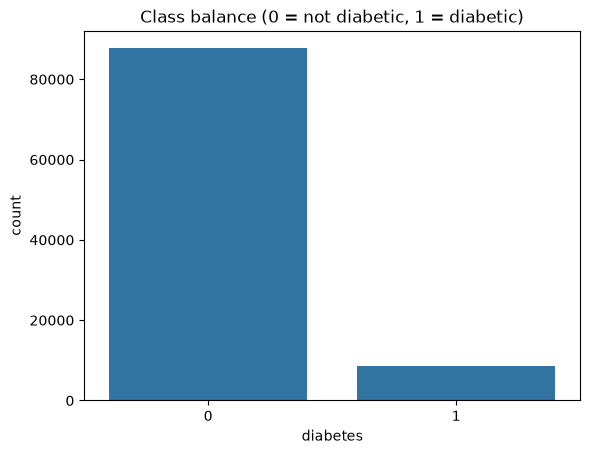

In [9]:
print(df["diabetes"].value_counts())
print((df["diabetes"].value_counts(normalize=True) * 100).round(1))

sns.countplot(x="diabetes", data=df, color="tab:blue")
plt.title("Class balance (0 = not diabetic, 1 = diabetic)")
plt.savefig("figures/kaggle/fig01_class_balance.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** After removing duplicates, **87,664 patients (91.2%) are not diabetic and 8,482 (8.8%) are**, a much stronger imbalance than Pima's 35%. A model that always says "not diabetic" would score 91.2% accuracy while catching nobody, so accuracy is useless here and we focus on recall and ROC-AUC with `class_weight="balanced"`.

## B.3 Feature distributions by diabetes

**Numeric features:** histograms coloured by class. Each class is scaled to the same area (`stat="density"`), because there are far fewer diabetics and we want to compare **shapes**, not counts.

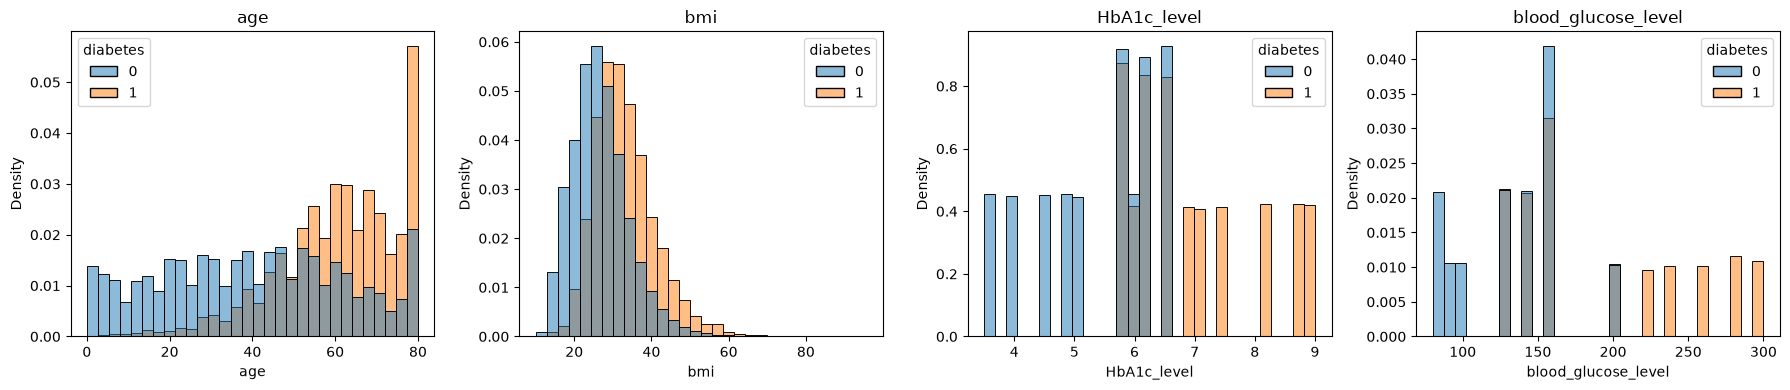

diabetes,0,1
age,40.00,62.00
bmi,25.96,31.85
HbA1c_level,5.80,6.60
blood_glucose_level,140.00,160.00


In [10]:
num_features = ["age", "bmi", "HbA1c_level", "blood_glucose_level"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, num_features):   # one small plot per feature
    sns.histplot(data=df, x=col, hue="diabetes", ax=ax, bins=30,
                 stat="density", common_norm=False,  # compare shapes, not counts
                 palette=["tab:blue", "tab:orange"])
    ax.set_title(col)
plt.tight_layout()
plt.savefig("figures/kaggle/fig02_histograms.png", dpi=150, bbox_inches="tight")
plt.show()

df.groupby("diabetes")[num_features].median().T

**Categorical and 0/1 features:** the share of diabetics in each group. If the bars differ a lot, that feature is related to diabetes.

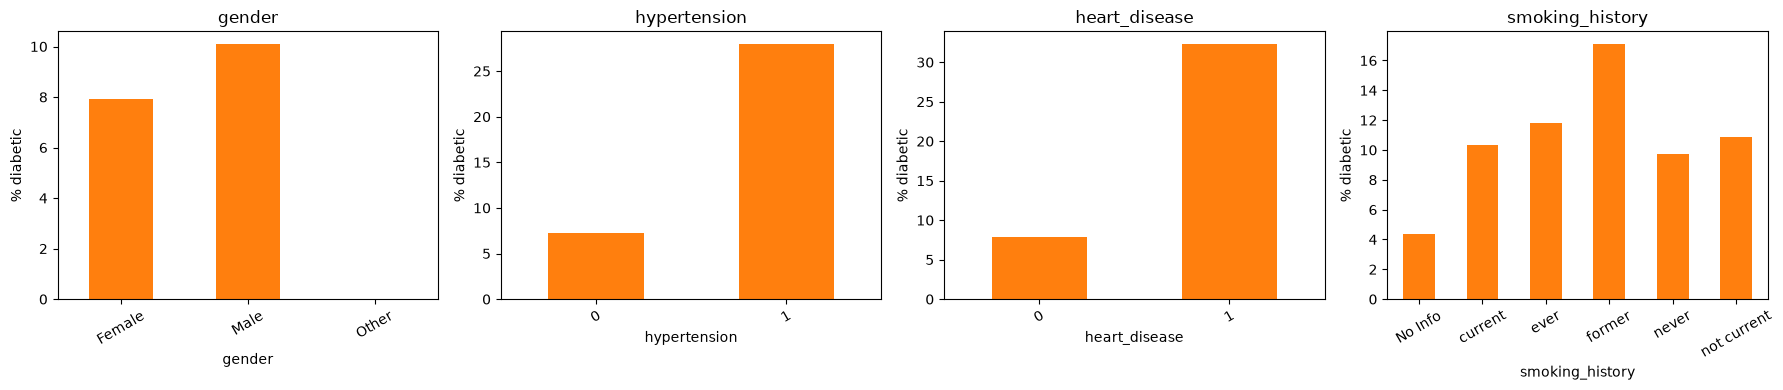

In [11]:
cat_features = ["gender", "hypertension", "heart_disease", "smoking_history"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, cat_features):
    rate = df.groupby(col)["diabetes"].mean() * 100   # % diabetic in each group
    rate.plot(kind="bar", ax=ax, color="tab:orange")
    ax.set_title(col)
    ax.set_ylabel("% diabetic")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("figures/kaggle/fig03_diabetes_rate_by_group.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** Diabetics are clearly **older** (median age 62 vs 40) and **heavier** (median BMI 31.85 vs 25.96). HbA1c and glucose take only a handful of values, and the highest values (HbA1c 6.8–9.0, glucose 220–300) appear **only in diabetics**. In the bar charts, the share of diabetics is much higher with **hypertension (about 28% vs 7%)** and **heart disease (about 32% vs 8%)**, a bit higher for men (about 10% vs 8%), highest for former smokers (about 17%) and lowest for "No Info" (about 4%).

## B.4 Outliers

A box plot shows the median (middle line), the quartiles $Q_1$ and $Q_3$ (box edges) and dots for outliers. We use the **IQR rule**:

$$IQR = Q_3 - Q_1 \qquad \text{outlier if } x < Q_1 - 1.5\,IQR \ \text{ or } \ x > Q_3 + 1.5\,IQR$$

The small function below counts outliers per column with this rule (same function as in the Pima notebook).

In [12]:
def count_outliers(df, columns):
    rows = []
    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        n = ((df[col] < lower) | (df[col] > upper)).sum()
        rows.append([col, lower, upper, n])
    return pd.DataFrame(rows, columns=["feature", "lower", "upper", "n_outliers"])

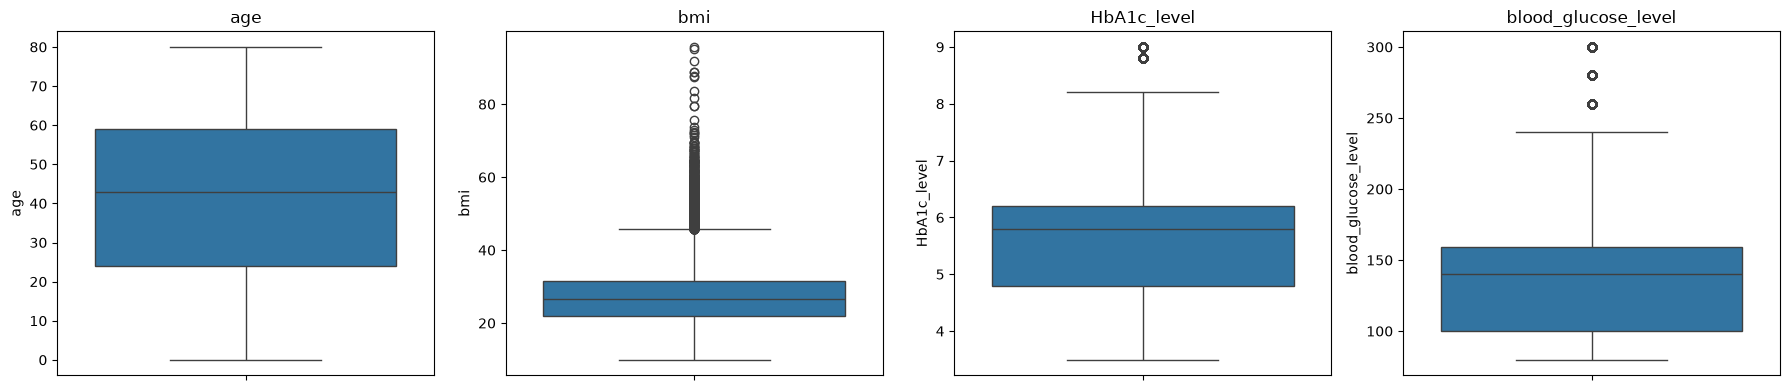

,feature,lower,upper,n_outliers
0,age,-28.50,111.5,0
1,bmi,7.77,45.8,1695
2,HbA1c_level,2.70,8.3,1312
3,blood_glucose_level,11.50,247.5,2031


In [13]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, num_features):
    sns.boxplot(y=df[col], ax=ax, color="tab:blue")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("figures/kaggle/fig04_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

count_outliers(df, num_features).round(2)

**Observation:** The IQR rule flags 1,695 BMI values above 45.8, 1,312 HbA1c values above 8.3 and 2,031 glucose values above 247.5. The HbA1c and glucose "outliers" are exactly the very high values that only diabetics have (B.3), so removing them would delete the clearest diabetic cases. Very high BMIs are possible in real patients. We **keep all of them**.

## B.5 Correlation

**Pearson correlation** $r$ measures how strongly two features rise or fall together in a straight line, from −1 to +1 (0 = no linear relation):

$$r = \frac{\text{cov}(X, Y)}{\sigma_X \, \sigma_Y}$$
($\text{cov}$ = covariance, $\sigma$ = standard deviation). Only the numeric and 0/1 columns are used; the text columns are left out.

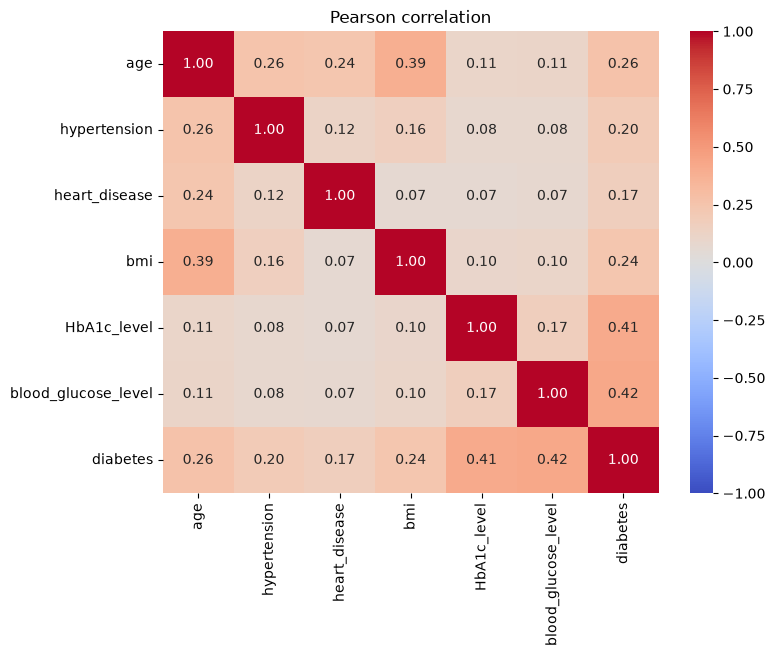

,diabetes,bmi
diabetes,1.000,0.238
blood_glucose_level,0.424,0.104
HbA1c_level,0.406,0.096
age,0.265,0.388
bmi,0.238,1.000
hypertension,0.196,0.163
heart_disease,0.171,0.069


In [14]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Pearson correlation")
plt.savefig("figures/kaggle/fig05_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

# correlation of each feature with the two targets, strongest first
corr[["diabetes", "bmi"]].sort_values("diabetes", ascending=False).round(3)

**Observation:** With `diabetes`, the strongest correlations are **blood glucose (0.424)** and **HbA1c (0.406)**, then age (0.265), BMI (0.238), hypertension (0.196) and heart disease (0.171). With **BMI** (our regression target), only **age (0.388)** is clearly correlated; hypertension (0.163), glucose (0.104) and HbA1c (0.096) are weak. This already suggests that BMI will be only partly predictable.

## B.6 How closely is the label tied to HbA1c and glucose?

If `diabetes` were defined purely by test cut-offs, there would be a value above which *every* patient is diabetic. We check the lowest and highest HbA1c and glucose in each class.

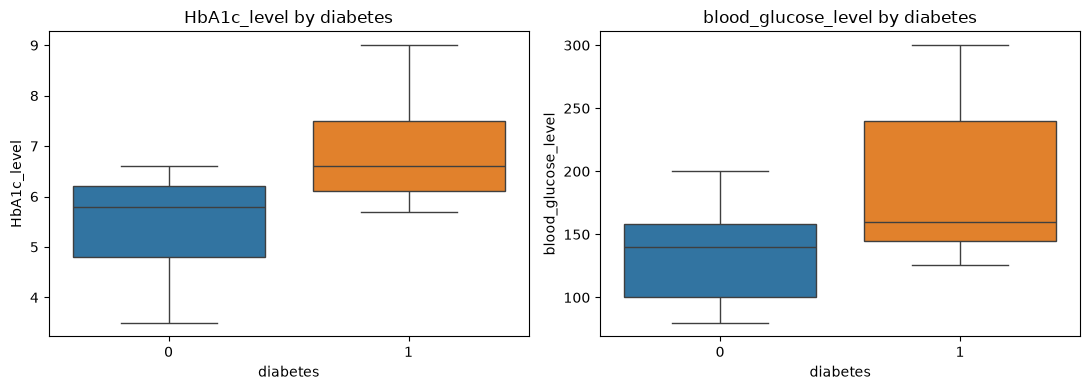

HbA1c_level      blood_glucose_level     
                 min  max                 min  max
diabetes                                          
0                3.5  6.6                  80  200
1                5.7  9.0                 126  300

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes, ["HbA1c_level", "blood_glucose_level"]):
    sns.boxplot(data=df, x="diabetes", y=col, ax=ax, hue="diabetes",
                palette=["tab:blue", "tab:orange"], legend=False)
    ax.set_title(col + " by diabetes")
plt.tight_layout()
plt.savefig("figures/kaggle/fig06_lab_values_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

df.groupby("diabetes")[["HbA1c_level", "blood_glucose_level"]].agg(["min", "max"])

**Observation:** Non-diabetics never have HbA1c above **6.6** or glucose above **200**, while diabetics start at 5.7 and 126. So **every patient with HbA1c above 6.6 or glucose above 200 is diabetic**: the label is largely defined by these two tests. This is why the "all features" model will be close to perfect and why we also build the "no blood test" model. (Some non-diabetics have HbA1c of 6.5–6.6, so the label is not a single clean cut-off.)

## B.7 Regression target: BMI (real values only)

Patients with a real BMI: 74480


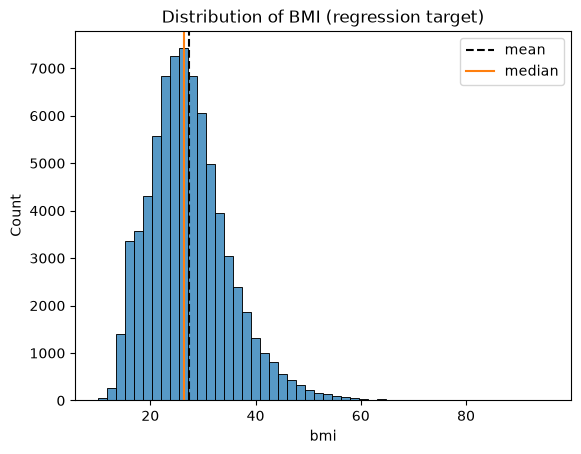

In [16]:
print("Patients with a real BMI:", df["bmi"].notnull().sum())

sns.histplot(df["bmi"].dropna(), bins=50, color="tab:blue")
plt.axvline(df["bmi"].mean(), color="black", linestyle="--", label="mean")
plt.axvline(df["bmi"].median(), color="tab:orange", label="median")
plt.legend()
plt.title("Distribution of BMI (regression target)")
plt.savefig("figures/kaggle/fig07_bmi_target.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** **74,480 patients have a real BMI.** Most lie between about 20 and 40, with a long right tail of very high values (up to about 95). This is the regression target, so the 22.5% filled-in values are left out of the regression.

## Key EDA Insights
1. **The label is largely defined by HbA1c and glucose**: everyone above HbA1c 6.6 or glucose 200 is diabetic. An "all features" model is therefore partly reading the answer, so we also train a **"no blood test"** model, which is the realistic screening question.
2. **Strong class imbalance (8.8% diabetic)**: accuracy is useless (91.2% by always saying "no"), so we use a stratified split, `class_weight="balanced"`, and recall + ROC-AUC.
3. **Hidden missing values in BMI**: 27.32 is a filled-in value for 22.5% of patients. We treat it as missing: imputed with the training median for classification and dropped for the BMI regression.
4. **3,854 duplicate rows** were removed, so no patient counts twice or appears in both train and test.
5. **Age, BMI, hypertension and heart disease** are the main non-lab risk signals (median age 62 vs 40; about 28% and 32% diabetic with hypertension and heart disease). These should drive the "no blood test" model.
6. **BMI is only weakly predictable**: only age correlates clearly with it (0.388), so we expect a modest R² for Ridge.
7. **Text columns** (`gender`, `smoking_history`) need **one-hot encoding**, and numeric features are on very different scales (glucose in the hundreds, HbA1c around 5–6), so linear models need **StandardScaler**. We keep the outliers, because the extreme lab values are exactly the diabetic cases.

# Section C: Preprocessing *(Rubric 3)*

**Data leakage** means information from the test set sneaking into training, for example computing the mean/std for scaling on *all* the data. The test score then looks better than it would on truly new patients.

To prevent it:
1. Split the data into train and test sets **first**.
2. Put every step that learns something from the data (imputation, scaling, encoding) inside a scikit-learn **`Pipeline`**. A pipeline learns those values from the training data only, and only *applies* them to the test data.

In [17]:
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

## C.1 Feature lists

| Used for | Numeric / 0-1 features | Text features |
|---|---|---|
| Classification, all features | age, hypertension, heart_disease, bmi, HbA1c_level, blood_glucose_level | gender, smoking_history |
| Classification, no blood test | age, hypertension, heart_disease, bmi | gender, smoking_history |
| Regression (target BMI) | age, hypertension, heart_disease, HbA1c_level, blood_glucose_level | gender, smoking_history |
| *(D.1 only: HbA1c as target)* | age, hypertension, heart_disease, bmi, blood_glucose_level | gender, smoking_history |

`diabetes` is never a feature for the regression.

In [18]:
CAT_COLS = ["gender", "smoking_history"]
NUM_ALL = ["age", "hypertension", "heart_disease", "bmi", "HbA1c_level", "blood_glucose_level"]
NUM_NO_LAB = ["age", "hypertension", "heart_disease", "bmi"]
NUM_REG = ["age", "hypertension", "heart_disease", "HbA1c_level", "blood_glucose_level"]
NUM_HBA1C = ["age", "hypertension", "heart_disease", "bmi", "blood_glucose_level"]   # D.1 only

## C.2 Train/test split

80% of patients for training and 20% for the final test. The test set is not touched again until the final evaluation.
We split **once**, with `stratify` on `diabetes` so both sets keep the same share of diabetics, and use the same split for both tasks. For regression we keep only the patients with a real BMI (the target).

In [19]:
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["diabetes"],
                                     random_state=RANDOM_STATE)

X_train = train_df.drop(columns=["diabetes"])                 # classification
y_train = train_df["diabetes"]
X_test = test_df.drop(columns=["diabetes"])
y_test = test_df["diabetes"]

reg_train = train_df.dropna(subset=["bmi"])                        # regression: real BMI only
reg_test = test_df.dropna(subset=["bmi"])
X_train_reg, y_train_reg = reg_train.drop(columns=["diabetes", "bmi"]), reg_train["bmi"]
X_test_reg, y_test_reg = reg_test.drop(columns=["diabetes", "bmi"]), reg_test["bmi"]

print("Train:", train_df.shape, " Test:", test_df.shape, " Regression rows:", len(reg_train), len(reg_test))
print("Diabetic share in train: %.3f   test: %.3f" % (y_train.mean(), y_test.mean()))

Train: (76916, 9)  Test: (19230, 9)  Regression rows: 59564 14916
Diabetic share in train: 0.088   test: 0.088


**Observation:** We have **76,916 training and 19,230 test patients**, with exactly the same diabetic share (0.088) in both thanks to stratification. For the regression, **59,564 training and 14,916 test patients** have a real BMI.

## C.3 Preprocessing steps

**1. One-hot encoding** of the text columns: each category becomes its own 0/1 column (e.g. `gender_Male`), because models only understand numbers.

**2. Median imputation** of missing numeric values, i.e. the hidden BMI values from B.1 (the median is learned from the training set).

**3. Standardisation:** each numeric feature is rescaled to mean 0 and standard deviation 1:

$$z = \frac{x - \mu}{\sigma}$$
($x$ = original value, $\mu$ = training mean of the feature, $\sigma$ = training standard deviation)

**Which models get scaled?**
- **Scaled:** Ridge and Logistic Regression. They use coefficients, so a feature with large numbers (glucose in the hundreds) would dominate one with small numbers (HbA1c around 5–6).
- **Not scaled:** Decision Tree and Random Forest. Trees split on one feature at a time ("HbA1c > 6.5?"), so the units do not matter.

A `ColumnTransformer` applies the numeric steps to the numeric columns and one-hot encoding to the text columns. As in the Pima notebook, two small functions build the pipelines so we don't repeat the same lines for every model.

In [20]:
def make_scaled_pipeline(model, num_cols):
    prep = ColumnTransformer([
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler", StandardScaler())]), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_COLS)],
        verbose_feature_names_out=False)    # keep plain names like "age", "gender_Male"
    return Pipeline([("prep", prep), ("model", model)])

def make_unscaled_pipeline(model, num_cols):
    prep = ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_COLS)],
        verbose_feature_names_out=False)    # keep plain names like "age", "gender_Male"
    return Pipeline([("prep", prep), ("model", model)])

## C.4 Checking that the pipeline prevents leakage

As a check, we fit just the preprocessing on the **training** set and compare the mean of each scaled column on train and test.

In [21]:
prep = make_scaled_pipeline(None, NUM_ALL).named_steps["prep"]   # preprocessing only
prep.fit(X_train)   # learns means, stds and categories from TRAINING data only

check = pd.DataFrame({
    "mean after scaling (train)": prep.transform(X_train).mean(axis=0),
    "mean after scaling (test)": prep.transform(X_test).mean(axis=0)},
    index=prep.get_feature_names_out())
check.round(3)

,mean after scaling (train),mean after scaling (test)
age,-0.000,0.007
hypertension,0.000,-0.008
heart_disease,-0.000,-0.002
bmi,0.000,0.006
HbA1c_level,-0.000,0.010
blood_glucose_level,-0.000,0.013
gender_Female,0.583,0.590
gender_Male,0.417,0.410
gender_Other,0.000,0.000
smoking_history_No Info,0.342,0.342


**Observation:** After scaling, every numeric training mean is 0, while the test means are close to but **not exactly 0** (at most 0.013 away). That shows the scaler learned its mean and standard deviation from the training set only. One-hot columns are 0/1, so their mean is simply the share of patients in that category (e.g. 58.3% female in train, 59.0% in test). `gender_Other` rounds to 0.000 because only 18 patients have it.

## C.5 Cross-validation setup

To compare models we use **5-fold cross-validation** on the training set only. The training data is cut into 5 parts; each model is trained 5 times, each time on 4 parts and scored on the remaining part. We report the **mean ± standard deviation** of the 5 scores:

$$\text{CV score} = \frac{1}{5}\sum_{k=1}^{5} \text{score}_k$$
($\text{score}_k$ = the score on fold $k$; the standard deviation shows how much the score changes from fold to fold)

`StratifiedKFold` keeps the same share of diabetics in every fold. `shuffle=True` with our seed mixes the rows first, in the same way on every run.

In [22]:
cv_class = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_reg = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Section D: Ridge Regression *(Rubric 3)*

## D.1 Why we do not predict HbA1c

Our first plan was to predict HbA1c from the other features. Two quick checks show that this cannot work in this dataset:
1. The CV $R^2$ of Ridge for HbA1c (the share of its variation explained).
2. Which HbA1c values occur in each class.

In [23]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_validate, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

hba1c_r2 = cross_val_score(make_scaled_pipeline(Ridge(), NUM_HBA1C), X_train, train_df["HbA1c_level"],
                           cv=cv_reg, scoring="r2")
print("Ridge CV R2 for HbA1c: %.3f +- %.3f" % (hba1c_r2.mean(), hba1c_r2.std()))
print()
print("HbA1c values in non-diabetics:", sorted(df.loc[df["diabetes"] == 0, "HbA1c_level"].unique()))
print("HbA1c values in diabetics:    ", sorted(df.loc[df["diabetes"] == 1, "HbA1c_level"].unique()))

Ridge CV R2 for HbA1c: 0.042 +- 0.004

HbA1c values in non-diabetics: [np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(4.8), np.float64(5.0), np.float64(5.7), np.float64(5.8), np.float64(6.0), np.float64(6.1), np.float64(6.2), np.float64(6.5), np.float64(6.6)]
HbA1c values in diabetics:     [np.float64(5.7), np.float64(5.8), np.float64(6.0), np.float64(6.1), np.float64(6.2), np.float64(6.5), np.float64(6.6), np.float64(6.8), np.float64(7.0), np.float64(7.5), np.float64(8.2), np.float64(8.8), np.float64(9.0)]


**Observation:** Ridge explains only **4.2% of HbA1c's variation** (CV R² 0.042 ± 0.004). The value lists show why: **6.8, 7.0, 7.5, 8.2, 8.8 and 9.0 occur only in diabetics**. In this dataset HbA1c follows the *diagnosis*, not age, BMI or the other routine features. Using `diabetes` as an input would be leakage (the diagnosis is made partly from HbA1c), so HbA1c cannot be honestly predicted here, and we use **BMI** as the regression target instead.

## D.2 Models (target: BMI)

| Model | Idea | Formula |
|---|---|---|
| Baseline | Always predict the training mean | $\hat{y} = \bar{y}$ |
| Ridge | Straight-line model + penalty on large coefficients | $\hat{y} = \beta_0 + \sum_j \beta_j x_j$, minimise $\sum_i (y_i - \hat{y}_i)^2 + \alpha \sum_j \beta_j^2$ |

$\beta_j$ = coefficient of feature $j$, $\alpha$ = penalty strength (bigger $\alpha$ = smaller coefficients).

In [24]:
reg_models = {
    "Baseline (mean)": make_unscaled_pipeline(DummyRegressor(), NUM_REG),
    "Ridge": make_scaled_pipeline(Ridge(), NUM_REG),
}

## D.3 Cross-validation

Each model is scored with 5-fold CV on the training set using:

$$\text{MAE} = \frac{1}{n}\sum|y_i - \hat{y}_i| \qquad \text{MSE} = \frac{1}{n}\sum(y_i - \hat{y}_i)^2 \qquad \text{RMSE} = \sqrt{\text{MSE}} \qquad R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

MAE and RMSE are in BMI units, kg/m² (lower is better); $R^2$ is the share of variation explained (higher is better).
scikit-learn returns errors as negative numbers (so that "higher is better" for every score), so we flip their sign.

In [25]:
rows = []
for name, model in reg_models.items():
    cv = cross_validate(model, X_train_reg, y_train_reg, cv=cv_reg, return_train_score=True,
                        scoring=["neg_mean_absolute_error", "neg_mean_squared_error", "r2"])
    mae = -cv["test_neg_mean_absolute_error"]   # flip the sign back to positive
    mse = -cv["test_neg_mean_squared_error"]
    rmse = np.sqrt(mse)                          # RMSE of each fold
    r2 = cv["test_r2"]
    rows.append([name, mae.mean(), mae.std(), mse.mean(), mse.std(), rmse.mean(), rmse.std(),
                 r2.mean(), r2.std(), cv["train_r2"].mean(), cv["fit_time"].mean()])

reg_cv = pd.DataFrame(rows, columns=["model", "MAE", "MAE std", "MSE", "MSE std", "RMSE",
                      "RMSE std", "R2", "R2 std", "R2 train", "fit time (s)"])
reg_cv = reg_cv.sort_values("R2", ascending=False)
reg_cv.round(3)

,model,MAE,MAE std,MSE,MSE std,RMSE,RMSE std,R2,R2 std,R2 train,fit time (s)
1,Ridge,5.275,0.024,48.333,0.946,6.952,0.068,0.18,0.006,0.181,0.048
0,Baseline (mean),5.930,0.017,58.962,0.724,7.679,0.047,-0.00,0.000,0.000,0.035


**Observation:** Ridge reaches **CV R² 0.180 ± 0.006** with RMSE 6.95, against 7.68 for the mean baseline. Its train R² (0.181) is the same as its CV R², so there is **no overfitting**. The model is simply limited by how little the features say about BMI. The tiny standard deviations show how stable scores are with about 60,000 patients.

## D.4 Tuning Ridge

Ridge's only important hyperparameter is the penalty strength $\alpha$: small $\alpha$ is close to plain Linear Regression, large $\alpha$ shrinks the coefficients more.
`GridSearchCV` tries every value with the same 5-fold CV and keeps the best one. `model__alpha` means "the `alpha` of the pipeline step called `model`".

In [26]:
alphas = {"model__alpha": [0.01, 0.1, 1, 10, 100, 1000, 10000]}

ridge_grid = GridSearchCV(make_scaled_pipeline(Ridge(), NUM_REG), alphas, cv=cv_reg, scoring="r2")
ridge_grid.fit(X_train_reg, y_train_reg)

print("Ridge best:", ridge_grid.best_params_, " CV R2 = %.4f" % ridge_grid.best_score_)

Ridge best: {'model__alpha': 100}  CV R2 = 0.1803


**Observation:** The best alpha is **100**, with CV R² 0.1803, practically identical to the default (alpha = 1). With about 60,000 patients and only 14 inputs, the penalty barely matters: there is plenty of data to estimate every coefficient.

## D.5 Final test-set evaluation

The tuned Ridge model is evaluated **once** on the test set, next to the mean baseline.

In [27]:
best_reg = ridge_grid.best_estimator_     # already refitted on the full training set
y_pred_reg = best_reg.predict(X_test_reg)
baseline_pred = np.full(len(y_test_reg), y_train_reg.mean())

print("Ridge     test MAE = %.2f  RMSE = %.2f  R2 = %.3f" % (
    mean_absolute_error(y_test_reg, y_pred_reg),
    root_mean_squared_error(y_test_reg, y_pred_reg), r2_score(y_test_reg, y_pred_reg)))
print("Baseline  test MAE = %.2f  RMSE = %.2f  R2 = %.3f" % (
    mean_absolute_error(y_test_reg, baseline_pred),
    root_mean_squared_error(y_test_reg, baseline_pred), r2_score(y_test_reg, baseline_pred)))

Ridge     test MAE = 5.30  RMSE = 7.04  R2 = 0.171
Baseline  test MAE = 5.93  RMSE = 7.73  R2 = -0.000


**Observation:** On the test set Ridge reaches **R² 0.171, RMSE 7.04 and MAE 5.30**, against R² −0.000, RMSE 7.73 and MAE 5.93 for the baseline. It **meets our criterion** (it clearly beats the baseline), and the test score is close to the CV score (0.180). It still explains only about 17% of the variation in BMI: a typical prediction is off by about 5–7 BMI points.

**Predicted vs actual:** points on the dashed line are perfect predictions. **Residual plot:** residual $= y - \hat{y}$; a good model has residuals scattered randomly around 0 with no pattern. With thousands of test patients the dots are drawn small and see-through.

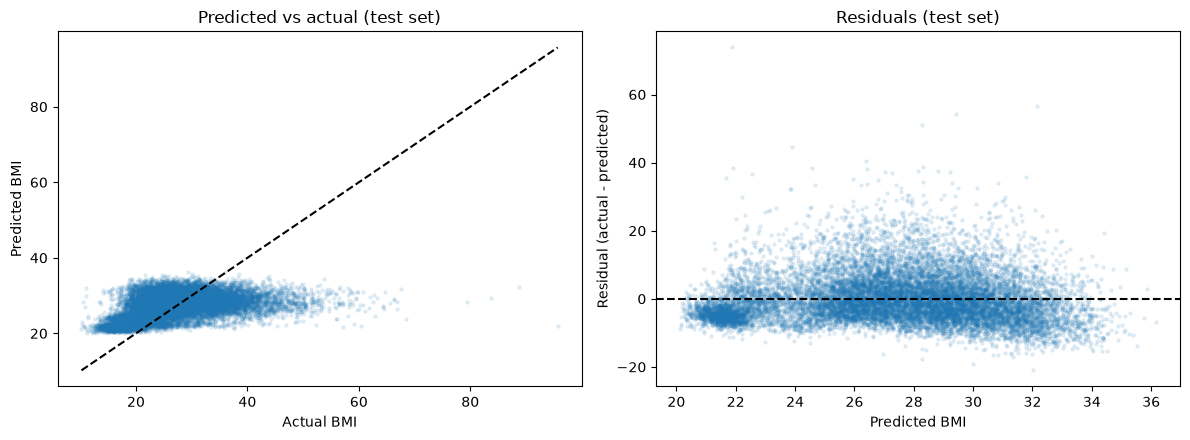

In [28]:
residuals = y_test_reg - y_pred_reg

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(y_test_reg, y_pred_reg, alpha=0.1, s=5)
lims = [y_test_reg.min(), y_test_reg.max()]
axes[0].plot(lims, lims, "k--")               # perfect-prediction line
axes[0].set_xlabel("Actual BMI")
axes[0].set_ylabel("Predicted BMI")
axes[0].set_title("Predicted vs actual (test set)")

axes[1].scatter(y_pred_reg, residuals, alpha=0.1, s=5)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_xlabel("Predicted BMI")
axes[1].set_ylabel("Residual (actual - predicted)")
axes[1].set_title("Residuals (test set)")
plt.tight_layout()
plt.savefig("figures/kaggle/fig08_reg_test_plots.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** Predictions stay in a narrow band (about 20–36) while real BMIs range from about 10 to over 90. The model **cannot predict very high BMIs** and pulls everyone towards the middle, so the residuals are large and positive for heavy patients. The dense cluster of predictions around 21–22 is most likely the children, since young age is the strongest signal for a low BMI.

## D.6 Ridge coefficients

Numeric features were standardised, so their coefficient is the change in predicted BMI for a **1 standard deviation increase**, keeping the others fixed. For one-hot columns (e.g. `gender_Male`) the coefficient compares that category with the others. The sign gives the direction and the size gives the strength.

In [29]:
ridge_names = best_reg.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(best_reg.named_steps["model"].coef_, index=ridge_names)
coefs.sort_values().round(3)

smoking_history_No Info       -2.063
heart_disease                 -0.224
gender_Other                  -0.045
gender_Male                   -0.043
smoking_history_not current    0.013
gender_Female                  0.088
smoking_history_never          0.272
HbA1c_level                    0.315
blood_glucose_level            0.366
hypertension                   0.442
smoking_history_ever           0.499
smoking_history_former         0.566
smoking_history_current        0.713
age                            2.434
dtype: float64

**Observation:** **Age** has by far the largest effect (+2.43 BMI points per SD): older patients are heavier, which mainly reflects children having low BMIs. **"No Info" smoking** lowers the predicted BMI by 2.06. This category is common among children (there is no smoking history to record), so it mostly acts as a stand-in for being young. Hypertension (+0.44), glucose (+0.37 per SD) and HbA1c (+0.32 per SD) go with a slightly higher BMI, matching the link between obesity and blood pressure and blood sugar. Gender has almost no effect.

# Section E: Classification *(Rubric 3)*

## E.1 Models

| Model | Idea | Formula |
|---|---|---|
| Logistic Regression | Linear score turned into a probability; trained by minimising log-loss | $\hat{p} = \sigma(z) = \frac{1}{1+e^{-z}},\ z = \beta_0 + \sum_j \beta_j x_j$; loss $= -\frac{1}{n}\sum [y\log\hat{p} + (1-y)\log(1-\hat{p})]$ |
| Decision Tree | Yes/no splits that make the groups as pure as possible | Gini $= 1 - \sum_c p_c^2$ |
| Random Forest | Majority vote of many trees, each on a random sample | $\hat{y} = \text{mode}\{T_1(x), \dots, T_B(x)\}$ |

$\sigma$ = sigmoid, $p_c$ = share of class $c$ in a node, $B$ = number of trees, $T_b$ = tree $b$.

**Class imbalance:** diabetics are a small minority (Section B.2), so all three models get `class_weight="balanced"`, which gives each class the weight $w_c = \frac{n}{2\, n_c}$ ($n$ = patients, $n_c$ = patients in class $c$). Mistakes on the smaller diabetic class then cost more.

The small function below builds the three models for a given list of numeric features, so we can train them on both feature sets. `n_jobs=-1` lets Random Forest use all CPU cores (it only changes speed, not results).

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay, RocCurveDisplay,
                             roc_auc_score, recall_score, precision_score)

def make_clf_models(num_cols):
    return {
        "Logistic Regression": make_scaled_pipeline(LogisticRegression(class_weight="balanced", max_iter=1000), num_cols),
        "Decision Tree": make_unscaled_pipeline(DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE), num_cols),
        "Random Forest": make_unscaled_pipeline(RandomForestClassifier(class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE), num_cols)}

feature_sets = {"all features": NUM_ALL, "no blood test": NUM_NO_LAB}

## E.2 Cross-validation

From the confusion matrix ($TP$ = diabetics caught, $FN$ = diabetics missed, $FP$ = false alarms, $TN$ = healthy correctly cleared):

$$\text{Accuracy} = \frac{TP+TN}{TP+TN+FP+FN} \quad \text{Precision} = \frac{TP}{TP+FP} \quad \text{Recall} = \frac{TP}{TP+FN} \quad F_1 = \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

**ROC-AUC** is the area under the curve of recall (true positive rate) against the false positive rate $\frac{FP}{FP+TN}$, over all thresholds: 0.5 = guessing, 1 = perfect.
Recall is our main metric, because missing a diabetic is worse than a false alarm. The table is sorted by it within each feature set. (This cell takes a few minutes: 3 models × 2 feature sets × 5 folds on about 77,000 patients.)

In [31]:
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

rows = []
for set_name, num_cols in feature_sets.items():
    for name, model in make_clf_models(num_cols).items():
        cv = cross_validate(model, X_train, y_train, cv=cv_class,
                            scoring=scoring, return_train_score=True)
        row = {"features": set_name, "model": name}
        for s in scoring:
            row[s] = cv["test_" + s].mean()
            row[s + " std"] = cv["test_" + s].std()
        row["roc_auc train"] = cv["train_roc_auc"].mean()   # used later to check overfitting
        row["fit time (s)"] = cv["fit_time"].mean()
        rows.append(row)

clf_cv = pd.DataFrame(rows).sort_values(["features", "recall"], ascending=[True, False])
clf_cv.round(3)

,features,model,accuracy,accuracy std,precision,precision std,recall,recall std,f1,f1 std,roc_auc,roc_auc std,roc_auc train,fit time (s)
0,all features,Logistic Regression,0.887,0.002,0.432,0.003,0.882,0.010,0.580,0.001,0.962,0.002,0.962,0.105
2,all features,Random Forest,0.958,0.001,0.764,0.003,0.754,0.008,0.759,0.004,0.967,0.001,1.000,0.581
1,all features,Decision Tree,0.952,0.001,0.726,0.009,0.728,0.010,0.727,0.008,0.851,0.005,1.000,0.181
3,no blood test,Logistic Regression,0.727,0.005,0.215,0.003,0.791,0.006,0.339,0.004,0.831,0.005,0.832,0.095
5,no blood test,Random Forest,0.824,0.001,0.219,0.002,0.390,0.009,0.281,0.004,0.756,0.006,0.993,0.649
4,no blood test,Decision Tree,0.834,0.003,0.197,0.006,0.284,0.009,0.232,0.006,0.581,0.004,0.995,0.198


**Observation:** **All features:** Random Forest has the best ROC-AUC (0.967), just ahead of Logistic Regression (0.962); the Decision Tree is clearly worse (0.851). Logistic Regression has the highest recall (0.882) thanks to class weighting. **No blood test:** Logistic Regression is far ahead (ROC-AUC 0.831, recall 0.791). The untuned Random Forest (0.756) and Decision Tree (0.581) are much worse, and both trees **overfit** (train ROC-AUC 0.993–1.000). Accuracy is again misleading: the all-features Random Forest has 95.8% accuracy but catches only 75% of diabetics. All standard deviations are tiny (≤ 0.01), so these differences are real.

## E.3 Tuning the best two models

For both feature sets the two best models by CV ROC-AUC are **Logistic Regression** and **Random Forest**; the Decision Tree is clearly behind (0.851 and 0.581).
We tune on **ROC-AUC rather than recall**: recall alone can be "won" by calling everyone diabetic, while ROC-AUC rewards ranking patients correctly. Recall is then raised with the threshold (E.5).
- Logistic Regression: `C` = how weakly the coefficients are penalised (small `C` = stronger penalty).
- Random Forest: `max_depth` (how deep each tree may grow) and `min_samples_leaf` (the smallest group a leaf may hold). Both limit overfitting.

In [32]:
grids = {}
for set_name, num_cols in feature_sets.items():
    models = make_clf_models(num_cols)
    grids[set_name + " | Logistic Regression"] = GridSearchCV(
        models["Logistic Regression"], {"model__C": [0.01, 0.1, 1, 10]},
        cv=cv_class, scoring="roc_auc").fit(X_train, y_train)
    grids[set_name + " | Random Forest"] = GridSearchCV(
        models["Random Forest"], {"model__max_depth": [None, 10], "model__min_samples_leaf": [1, 10]},
        cv=cv_class, scoring="roc_auc").fit(X_train, y_train)

for key, grid in grids.items():
    print(key, grid.best_params_, " CV ROC-AUC = %.4f" % grid.best_score_)

all features | Logistic Regression {'model__C': 0.01}  CV ROC-AUC = 0.9623
all features | Random Forest {'model__max_depth': None, 'model__min_samples_leaf': 10}  CV ROC-AUC = 0.9758
no blood test | Logistic Regression {'model__C': 0.01}  CV ROC-AUC = 0.8313
no blood test | Random Forest {'model__max_depth': 10, 'model__min_samples_leaf': 10}  CV ROC-AUC = 0.8307


**Observation:** Tuning helps the **Random Forest** a lot. With `min_samples_leaf = 10` (each leaf must hold at least 10 patients) it improves to **0.9758** with all features. For no blood test, `max_depth = 10` and `min_samples_leaf = 10` lift it from 0.756 to **0.8307**. Logistic Regression barely changes (best C = 0.01: 0.9623 and 0.8313). Final models: **Random Forest** for all features, and **Logistic Regression** for no blood test (0.8313 vs 0.8307, practically a tie, so the simpler and more interpretable model wins).

For each feature set, the tuned model with the higher CV ROC-AUC becomes the final model.

In [33]:
best_clf, best_name = {}, {}
for set_name in feature_sets:
    lr = grids[set_name + " | Logistic Regression"]
    rf = grids[set_name + " | Random Forest"]
    if lr.best_score_ >= rf.best_score_:
        best_clf[set_name], best_name[set_name] = lr.best_estimator_, "Logistic Regression"
    else:
        best_clf[set_name], best_name[set_name] = rf.best_estimator_, "Random Forest"
best_name

{'all features': 'Random Forest', 'no blood test': 'Logistic Regression'}

## E.4 Final test-set evaluation (threshold 0.5)

Each final model is evaluated once on the test set. We turn its probabilities into labels ourselves ($\hat{p} \ge 0.5$), so the same rule is used in the threshold analysis below.

In [34]:
test_proba = {}
for set_name, model in best_clf.items():
    test_proba[set_name] = model.predict_proba(X_test)[:, 1]   # probability of diabetes
    y_pred = (test_proba[set_name] >= 0.5).astype(int)
    print("=====", set_name, "(" + best_name[set_name] + ")  test ROC-AUC = %.3f"
          % roc_auc_score(y_test, test_proba[set_name]))
    print(classification_report(y_test, y_pred, target_names=["not diabetic", "diabetic"]))

===== all features (Random Forest)  test ROC-AUC = 0.974
              precision    recall  f1-score   support

not diabetic       0.99      0.91      0.95     17534
    diabetic       0.50      0.89      0.64      1696

    accuracy                           0.91     19230
   macro avg       0.74      0.90      0.80     19230
weighted avg       0.95      0.91      0.92     19230

===== no blood test (Logistic Regression)  test ROC-AUC = 0.825
              precision    recall  f1-score   support

not diabetic       0.97      0.71      0.82     17534
    diabetic       0.21      0.79      0.33      1696

    accuracy                           0.72     19230
   macro avg       0.59      0.75      0.58     19230
weighted avg       0.90      0.72      0.78     19230



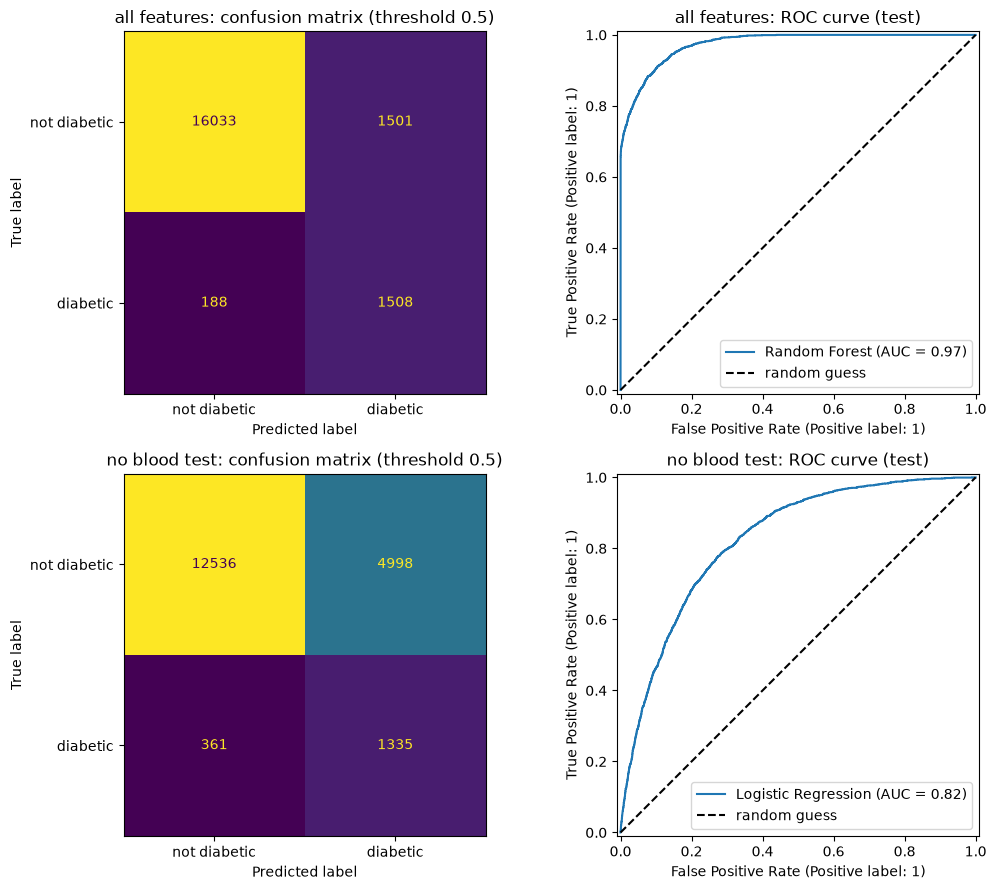

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for i, set_name in enumerate(feature_sets):
    y_pred = (test_proba[set_name] >= 0.5).astype(int)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[i, 0], colorbar=False,
                                            display_labels=["not diabetic", "diabetic"])
    axes[i, 0].set_title(set_name + ": confusion matrix (threshold 0.5)")
    RocCurveDisplay.from_predictions(y_test, test_proba[set_name], ax=axes[i, 1], name=best_name[set_name])
    axes[i, 1].plot([0, 1], [0, 1], "k--", label="random guess")
    axes[i, 1].legend(loc="lower right")
    axes[i, 1].set_title(set_name + ": ROC curve (test)")
plt.tight_layout()
plt.savefig("figures/kaggle/fig09_clf_test_cm_roc.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** **All features (Random Forest):** test ROC-AUC **0.974**; at threshold 0.5 it catches 89% of diabetics, but only half of its alarms are correct (precision 0.50). **No blood test (Logistic Regression):** test ROC-AUC **0.825**, recall 0.79, but precision only 0.21: about 1 in 5 flagged patients is diabetic. Its accuracy (0.72) is below the 91.2% "always no" baseline, which again shows accuracy is the wrong metric here.

## E.5 Threshold analysis

A patient is flagged as diabetic if $\hat{p} \ge t$. Lowering $t$ flags more patients: **recall goes up, precision goes down**.
We must **not** choose $t$ by looking at the test set, as that would be leakage. Instead we get out-of-fold probabilities for the training patients with `cross_val_predict` (each patient is predicted by a model that did not see them) and choose $t$ from those.

**Rule (fixed in advance):** for each feature set, use the **highest threshold whose training-CV recall reaches our 0.75 target**. It keeps false alarms as low as possible while meeting the target.

In [36]:
threshold_tables, THRESHOLD = {}, {}
for set_name, model in best_clf.items():
    train_proba = cross_val_predict(model, X_train, y_train, cv=cv_class, method="predict_proba")[:, 1]
    rows = []
    for t in [0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]:
        flagged = (train_proba >= t).astype(int)
        rows.append([t, recall_score(y_train, flagged), precision_score(y_train, flagged), flagged.mean()])
    table = pd.DataFrame(rows, columns=["threshold", "recall", "precision", "share flagged"])
    threshold_tables[set_name] = table
    THRESHOLD[set_name] = table.loc[table["recall"] >= 0.75, "threshold"].max()   # the rule above

print("Chosen thresholds:", THRESHOLD)
pd.concat(threshold_tables, names=["features"]).round(3)

Chosen thresholds: {'all features': np.float64(0.7), 'no blood test': np.float64(0.5)}


threshold  recall  precision  share flagged
features                                                    
all features  0        0.9   0.634      0.996          0.056
              1        0.8   0.716      0.906          0.070
              2        0.7   0.788      0.748          0.093
              3        0.6   0.849      0.619          0.121
              4        0.5   0.895      0.515          0.153
              5        0.4   0.931      0.434          0.189
              6        0.3   0.958      0.376          0.225
              7        0.2   0.977      0.323          0.267
              8        0.1   0.990      0.246          0.355
no blood test 0        0.9   0.100      0.469          0.019
              1        0.8   0.310      0.365          0.075
              2        0.7   0.511      0.302          0.149
              3        0.6   0.678      0.254          0.236
              4        0.5   0.791      0.216          0.324
              5        0.4   0.876      0.185          0.418
              6        0.3   0.931      0.158          0.521
              7        0.2   0.967      0.134          0.637
              8        0.1   0.987      0.112          0.781

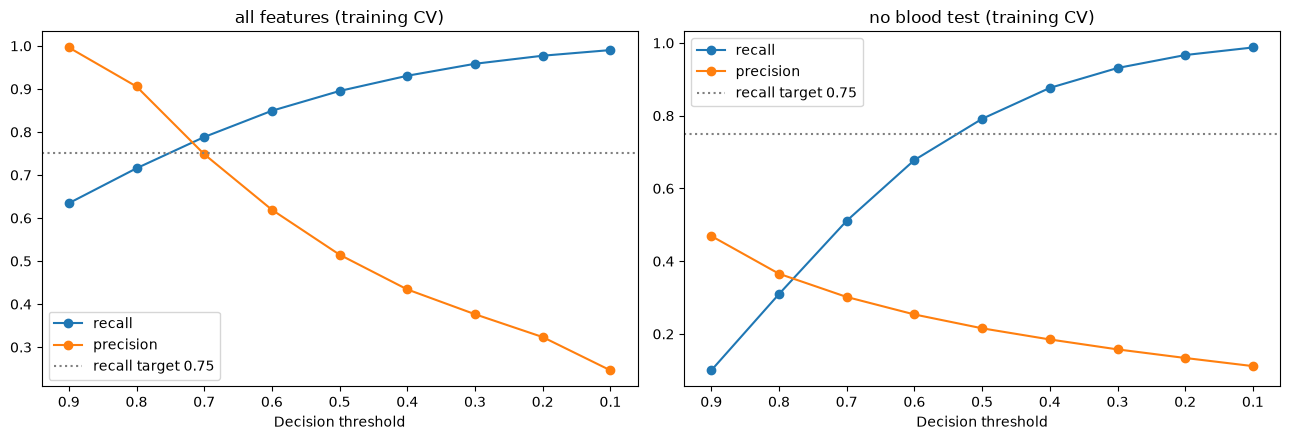

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (set_name, table) in zip(axes, threshold_tables.items()):
    ax.plot(table["threshold"], table["recall"], marker="o", label="recall")
    ax.plot(table["threshold"], table["precision"], marker="o", label="precision")
    ax.axhline(0.75, color="gray", linestyle=":", label="recall target 0.75")
    ax.invert_xaxis()                       # read left to right: 0.5 -> lower
    ax.set_xlabel("Decision threshold")
    ax.set_title(set_name + " (training CV)")
    ax.legend()
plt.tight_layout()
plt.savefig("figures/kaggle/fig10_clf_threshold.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** **All features:** recall stays above 0.75 up to **t = 0.7** (CV recall 0.788, precision 0.748), so the rule picks 0.7, which cuts false alarms sharply compared with 0.5 (precision 0.515). **No blood test:** recall drops below the target already at t = 0.6 (0.678), so the rule keeps **t = 0.5** (recall 0.791, precision 0.216, 32.4% of patients flagged).

Now each final model is applied to the test set **once**, with its chosen threshold.

all features : test recall = 0.784, precision = 0.729
no blood test : test recall = 0.787, precision = 0.211


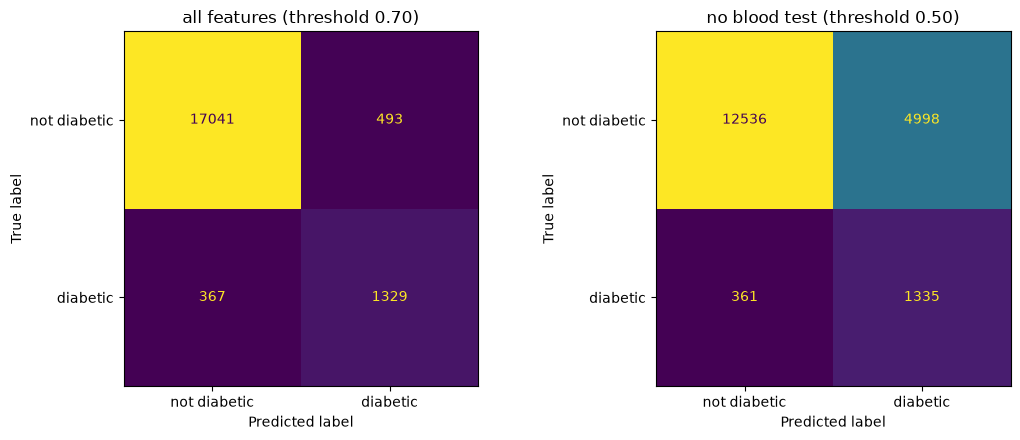

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
y_screen = {}
for ax, set_name in zip(axes, feature_sets):
    y_screen[set_name] = (test_proba[set_name] >= THRESHOLD[set_name]).astype(int)
    print(set_name, ": test recall = %.3f, precision = %.3f" % (
        recall_score(y_test, y_screen[set_name]), precision_score(y_test, y_screen[set_name])))
    ConfusionMatrixDisplay.from_predictions(y_test, y_screen[set_name], ax=ax, colorbar=False,
                                            display_labels=["not diabetic", "diabetic"])
    ax.set_title("%s (threshold %.2f)" % (set_name, THRESHOLD[set_name]))
plt.tight_layout()
plt.savefig("figures/kaggle/fig11_clf_cm_screening.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** With their chosen thresholds both models **meet the recall target on the test set**. The all-features Random Forest (t = 0.7) reaches **recall 0.784 and precision 0.729**, and the no-blood-test Logistic Regression (t = 0.5) reaches **recall 0.787 and precision 0.211**. They catch about the same share of diabetics, but the no-blood-test model needs about 3.5 times as many alarms per diabetic found (1 / 0.211 ≈ 4.7 vs 1 / 0.729 ≈ 1.4). That is the price of not using a blood test.

# Section F: Comparative Performance Analysis *(Rubric 4)*

## F.1 Comparison table

We fit every (untuned) model on the full training set and score it once on the test set, then put it next to its train and CV scores.
Comparing **train vs CV vs test** shows overfitting: a model that is much better on train than on CV/test has memorised the training data.
Test recall uses each model's default `predict()`, the same rule as the CV recall in E.2.

In [39]:
clf_test_recall, clf_test_auc, clf_proba = {}, {}, {}
for set_name, num_cols in feature_sets.items():
    for name, model in make_clf_models(num_cols).items():
        model.fit(X_train, y_train)
        key = set_name + " | " + name
        clf_proba[key] = model.predict_proba(X_test)[:, 1]
        clf_test_recall[key] = recall_score(y_test, model.predict(X_test))
        clf_test_auc[key] = roc_auc_score(y_test, clf_proba[key])

clf_compare = clf_cv[["features", "model", "recall", "recall std", "roc_auc train",
                      "roc_auc", "roc_auc std", "fit time (s)"]].copy()
keys = clf_compare["features"] + " | " + clf_compare["model"]
clf_compare["recall test"] = keys.map(clf_test_recall)
clf_compare["roc_auc test"] = keys.map(clf_test_auc)
clf_compare.round(3)

,features,model,recall,recall std,roc_auc train,roc_auc,roc_auc std,fit time (s),recall test,roc_auc test
0,all features,Logistic Regression,0.882,0.010,0.962,0.962,0.002,0.105,0.880,0.960
2,all features,Random Forest,0.754,0.008,1.000,0.967,0.001,0.581,0.754,0.965
1,all features,Decision Tree,0.728,0.010,1.000,0.851,0.005,0.181,0.744,0.858
3,no blood test,Logistic Regression,0.791,0.006,0.832,0.831,0.005,0.095,0.787,0.825
5,no blood test,Random Forest,0.390,0.009,0.993,0.756,0.006,0.649,0.373,0.745
4,no blood test,Decision Tree,0.284,0.009,0.995,0.581,0.004,0.198,0.275,0.571


**Observation:** Test scores are **very close to CV scores** for every model (e.g. all-features Random Forest 0.965 vs 0.967; no-blood-test Logistic Regression 0.825 vs 0.831). With about 19,000 test patients the test set is reliable, unlike Pima's 154. The tree models overfit (train ROC-AUC 0.993–1.000 vs CV 0.58–0.97). Logistic Regression's train, CV and test scores are almost identical.

For regression, Ridge is compared with the mean baseline in the same way.

In [40]:
reg_test = {}
for name, model in reg_models.items():
    model.fit(X_train_reg, y_train_reg)
    reg_test[name] = r2_score(y_test_reg, model.predict(X_test_reg))

reg_compare = reg_cv[["model", "R2 train", "R2", "R2 std", "RMSE", "fit time (s)"]].copy()
reg_compare = reg_compare.rename(columns={"R2": "R2 CV", "R2 std": "R2 CV std", "RMSE": "RMSE CV"})
reg_compare["R2 test"] = reg_compare["model"].map(reg_test)
reg_compare.round(3)

,model,R2 train,R2 CV,R2 CV std,RMSE CV,fit time (s),R2 test
1,Ridge,0.181,0.18,0.006,6.952,0.048,0.171
0,Baseline (mean),0.000,-0.00,0.000,7.679,0.035,-0.000


**Observation:** Ridge has the same R² on train (0.181), CV (0.180) and test (0.171), so it is stable and **not overfitting**. Its limit is how little the features say about BMI, not the model.

## F.2 Main metric with CV error bars

Each bar is the CV mean; the black line is ± 1 standard deviation across the 5 folds. If two error bars overlap a lot, the difference between those models is not reliable.

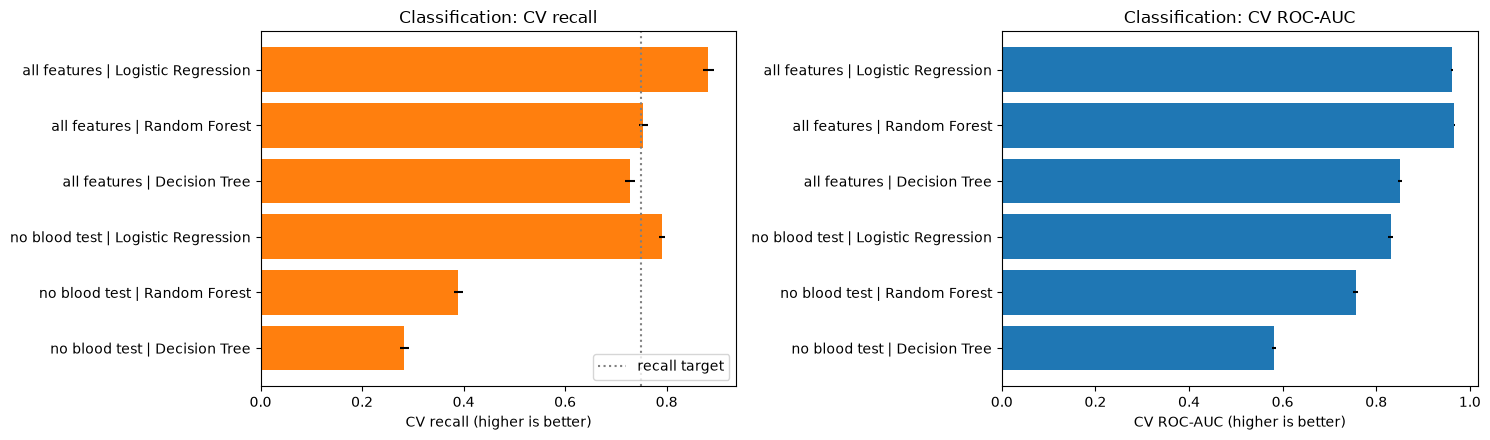

In [41]:
labels = clf_cv["features"] + " | " + clf_cv["model"]

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
axes[0].barh(labels, clf_cv["recall"], xerr=clf_cv["recall std"], color="tab:orange")
axes[0].axvline(0.75, color="gray", linestyle=":", label="recall target")
axes[0].set_xlabel("CV recall (higher is better)")
axes[0].set_title("Classification: CV recall")
axes[0].invert_yaxis()
axes[0].legend(loc="lower right")

axes[1].barh(labels, clf_cv["roc_auc"], xerr=clf_cv["roc_auc std"], color="tab:blue")
axes[1].set_xlabel("CV ROC-AUC (higher is better)")
axes[1].set_title("Classification: CV ROC-AUC")
axes[1].invert_yaxis()
plt.tight_layout()
plt.savefig("figures/kaggle/fig12_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** The error bars are tiny (CV std ≤ 0.01), so the gaps between models are **real**, unlike in our Pima notebook. With all features, Logistic Regression has the highest recall at the default threshold. Without blood tests, only Logistic Regression comes close to the 0.75 recall line; the untuned trees are far below it.

## F.3 ROC curves of all classifiers (test set)

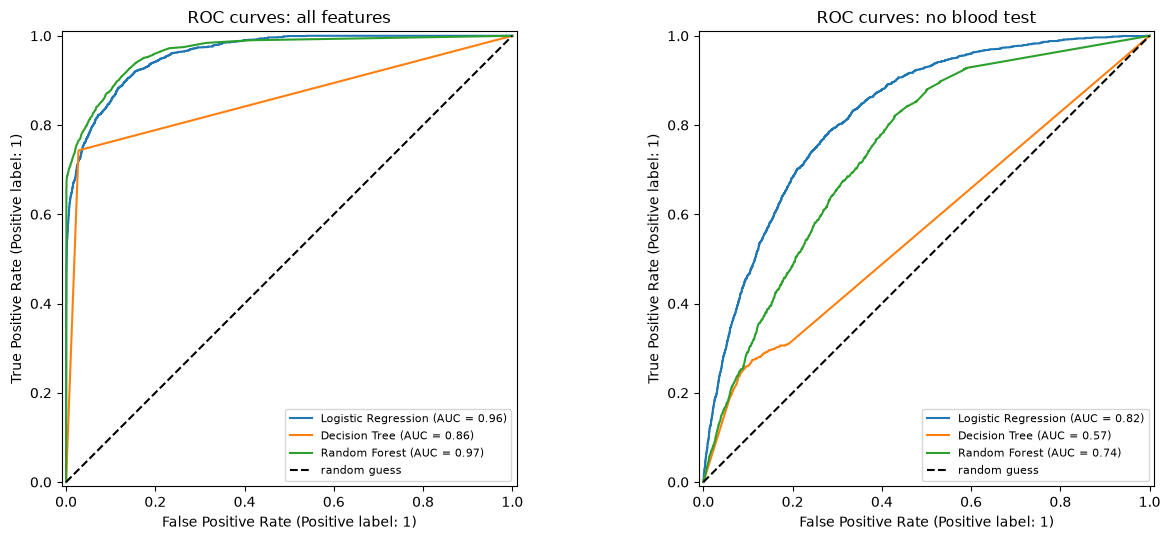

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, set_name in zip(axes, feature_sets):
    for key, proba in clf_proba.items():
        if key.startswith(set_name):
            RocCurveDisplay.from_predictions(y_test, proba, name=key.split(" | ")[1], ax=ax)
    ax.plot([0, 1], [0, 1], "k--", label="random guess")
    ax.legend(fontsize=8, loc="lower right")
    ax.set_title("ROC curves: " + set_name)
plt.tight_layout()
plt.savefig("figures/kaggle/fig13_roc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** With all features, the Logistic Regression and Random Forest curves hug the top-left corner (ROC-AUC 0.960 and 0.965 untuned), while the Decision Tree's curve has only a few corners (0.858). Without blood tests, all curves are lower: Logistic Regression is best (0.825), and the untuned Decision Tree is close to the diagonal (0.571), i.e. barely better than guessing.

## F.4 Before vs after tuning

"Before" = default settings, "after" = best settings from `GridSearchCV`, both scored with ROC-AUC for classification and $R^2$ for Ridge. `grid.score()` uses the same metric the grid search was tuned on.

In [43]:
c = clf_cv.set_index(clf_cv["features"] + " | " + clf_cv["model"])

rows = []
for key, grid in grids.items():
    rows.append([key, c.loc[key, "roc_auc"], grid.best_score_,
                 clf_test_auc[key], grid.score(X_test, y_test)])
rows.append(["Ridge (R2)", reg_cv.set_index("model").loc["Ridge", "R2"], ridge_grid.best_score_,
             reg_test["Ridge"], ridge_grid.score(X_test_reg, y_test_reg)])

tuning = pd.DataFrame(rows, columns=["model", "CV before", "CV after", "test before", "test after"])
tuning.round(4)

,model,CV before,CV after,test before,test after
0,all features | Logistic Regression,0.9622,0.9623,0.9600,0.9600
1,all features | Random Forest,0.9669,0.9758,0.9653,0.9745
2,no blood test | Logistic Regression,0.8313,0.8313,0.8248,0.8248
3,no blood test | Random Forest,0.7558,0.8307,0.7449,0.8259
4,Ridge (R2),0.1803,0.1803,0.1706,0.1706


**Observation:** Tuning **clearly helped the Random Forest**: CV ROC-AUC rose from 0.9669 to 0.9758 (test 0.9653 → 0.9745) with all features, and from 0.7558 to 0.8307 (test 0.7449 → 0.8259) without blood tests. Limiting leaf size stops the trees from memorising individual patients. Logistic Regression and Ridge did not change, because simple linear models with plenty of data have little to tune. Unlike in Pima, tuning paid off here: with about 77,000 training patients the CV scores are precise enough for tuning to find real improvements.

## F.5 Analysis
**Which model wins, and why?**
- **All features:** the tuned **Random Forest** (test ROC-AUC 0.974). HbA1c and glucose relate to the label through cut-offs ("above 6.6 means diabetic"), and trees model such thresholds naturally, while Logistic Regression can only draw one straight boundary. It needed tuning (`min_samples_leaf = 10`) to stop memorising patients.
- **No blood test:** **Logistic Regression** (test ROC-AUC 0.825). Risk rises smoothly with age and BMI, which a straight-line model captures well. A tuned Random Forest only matches it (0.8307 vs 0.8313 in CV), so the simpler model wins.
- **Regression:** Ridge clearly beats the baseline but explains only about 17% of BMI; the features carry little information about weight.

**Is the difference meaningful?**
- Yes, mostly: with tens of thousands of patients the CV standard deviations are at most 0.01, and test scores match CV scores. The one exception is the near-tie without blood tests (tuned LR 0.8313 vs tuned RF 0.8307).

**Accuracy vs interpretability**
- With all features, Random Forest is only slightly better than Logistic Regression in ROC-AUC (0.976 vs 0.962 CV), and both mostly rely on the lab values that define the label. The extra accuracy is not worth much clinically, because a doctor with these test results would diagnose diabetes directly.
- For the **real screening question** (no blood test), the simplest and most interpretable model, Logistic Regression, is also the best, so there is no trade-off.

# Section G: Explainability *(Rubric 5)*

We explain the final model of each feature set and, for comparison, the tuned **Logistic Regression** (LR), which is easy to read directly.

## G.1 Logistic Regression: coefficients and odds ratios

LR models the **log-odds** of diabetes as a straight line: $\log\frac{p}{1-p} = \beta_0 + \sum_j \beta_j x_j$.
So a 1-unit increase in $x_j$ multiplies the odds $\frac{p}{1-p}$ by the **odds ratio** $e^{\beta_j}$. Numeric features are standardised, so "1 unit" there means **1 standard deviation**; for one-hot columns it means "being in that category". OR > 1 raises risk, OR < 1 lowers it.

In [44]:
import shap
from sklearn.inspection import permutation_importance

odds = {}
for set_name in feature_sets:
    lr_best = grids[set_name + " | Logistic Regression"].best_estimator_
    names = lr_best.named_steps["prep"].get_feature_names_out()
    odds[set_name] = pd.Series(np.exp(lr_best.named_steps["model"].coef_[0]), index=names)

odds = pd.DataFrame(odds)    # features missing from a set show as NaN
odds.sort_values("all features", ascending=False).round(3)

,all features,no blood test
HbA1c_level,8.551,NaN
blood_glucose_level,3.449,NaN
age,2.991,3.087
bmi,1.827,1.823
hypertension,1.229,1.252
heart_disease,1.166,1.174
gender_Male,1.164,1.191
smoking_history_current,1.130,1.225
smoking_history_former,1.097,1.064
smoking_history_ever,1.063,1.050


**Observation:** **With all features**, the odds ratios are dominated by the lab values: **HbA1c 8.55 per SD and glucose 3.45 per SD**, followed by age (2.99) and BMI (1.83). **Without blood tests**, **age (3.09 per SD)** and **BMI (1.82 per SD)** lead, followed by hypertension (1.25), current smoking (1.23), heart disease (1.17) and being male (1.19). "No Info" smoking lowers the odds (0.67), and being female lowers them slightly (0.85).

## G.2 Permutation importance (test set)

Shuffle one feature's values on the test set and measure how much ROC-AUC drops. A big drop means the model relies on that feature:

$$\text{importance}_j = \text{score}(\text{original}) - \text{score}(\text{feature } j \text{ shuffled})$$

The shuffle is repeated 5 times and averaged (fewer repeats than for Pima, because the test set is much larger and the results are already stable). It works the same way for any model. A text column like `smoking_history` is shuffled as a whole.

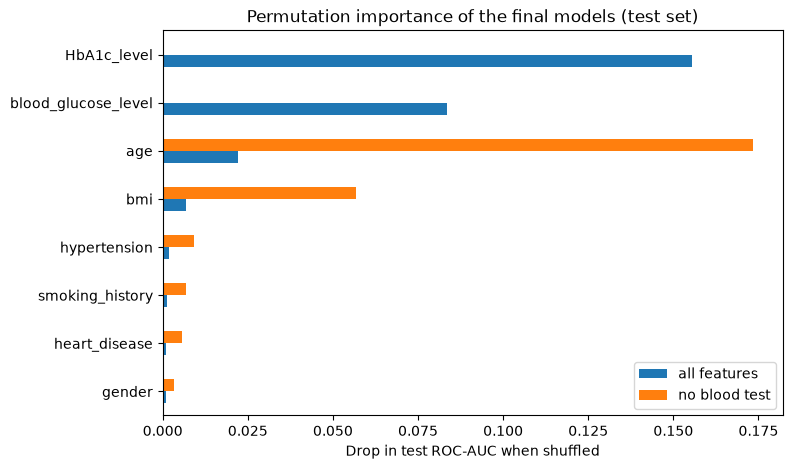

,all features,no blood test
HbA1c_level,0.155,0.000
blood_glucose_level,0.084,0.000
age,0.022,0.173
bmi,0.007,0.057
hypertension,0.002,0.009
smoking_history,0.001,0.007
heart_disease,0.001,0.006
gender,0.001,0.003


In [45]:
perm = {}
for set_name, model in best_clf.items():
    result = permutation_importance(model, X_test, y_test, scoring="roc_auc",
                                    n_repeats=5, random_state=RANDOM_STATE)
    perm[set_name] = pd.Series(result.importances_mean, index=X_test.columns)

perm = pd.DataFrame(perm)
perm.sort_values("all features").plot(kind="barh", figsize=(8, 5))
plt.xlabel("Drop in test ROC-AUC when shuffled")
plt.title("Permutation importance of the final models (test set)")
plt.savefig("figures/kaggle/fig14_permutation_importance.png", dpi=150, bbox_inches="tight")
plt.show()

perm.sort_values("all features", ascending=False).round(3)

**Observation:** The **all-features** Random Forest depends mostly on **HbA1c (0.155 drop in ROC-AUC)** and **glucose (0.084)**; age (0.022) and BMI (0.007) add little once the lab values are known. The **no-blood-test** Logistic Regression depends mostly on **age (0.173)** and then **BMI (0.057)**. Hypertension, smoking, heart disease and gender each matter much less (≤ 0.009). The lab columns show 0 for this model because it never uses them.

## G.3 SHAP values

SHAP gives each feature a fair share of the credit for one prediction, using the **Shapley value** from game theory: the feature's average contribution over all possible orders of adding the features:

$$\phi_j = \sum_{S \subseteq F \setminus \{j\}} \frac{|S|!\,(|F|-|S|-1)!}{|F|!}\,\big[f(S \cup \{j\}) - f(S)\big]$$

($F$ = all features, $S$ = a subset without $j$, $f(S)$ = the prediction using only the features in $S$.) The values always add up exactly:

$$\text{prediction} = \text{base value} + \sum_j \phi_j$$

We use **TreeExplainer** for a Random Forest (it reads the trees directly, so it is fast and exact) and **LinearExplainer** for Logistic Regression. SHAP works on the model's input, i.e. *after* preprocessing, so one-hot columns appear separately. To keep it fast we explain a random sample of 500 test patients, with 200 training patients as background.

In [46]:
def explain(model, n=500):
    prep, clf = model.named_steps["prep"], model.named_steps["model"]
    names = prep.get_feature_names_out()
    background = pd.DataFrame(prep.transform(X_train.sample(200, random_state=RANDOM_STATE)), columns=names)
    sample = pd.DataFrame(prep.transform(X_test.sample(n, random_state=RANDOM_STATE)), columns=names)
    if isinstance(clf, RandomForestClassifier):
        values = shap.TreeExplainer(clf)(sample)[:, :, 1]   # forests give values per class; keep "diabetic"
    else:
        values = shap.LinearExplainer(clf, background)(sample)
        # LR sees standardised numbers; turn them back into real units for the plots
        scaler = prep.named_transformers_["num"].named_steps["scaler"]
        k = len(scaler.mean_)                       # numeric columns come first
        data = values.data.copy()                   # SHAP's array is read-only, so work on a copy
        data[:, :k] = scaler.inverse_transform(data[:, :k])
        values.data = data
    return values

shap_values = {set_name: explain(model) for set_name, model in best_clf.items()}

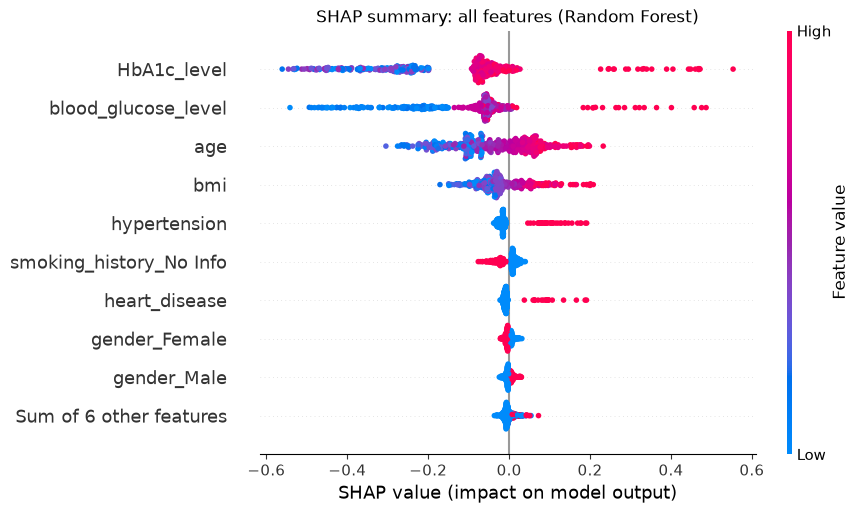

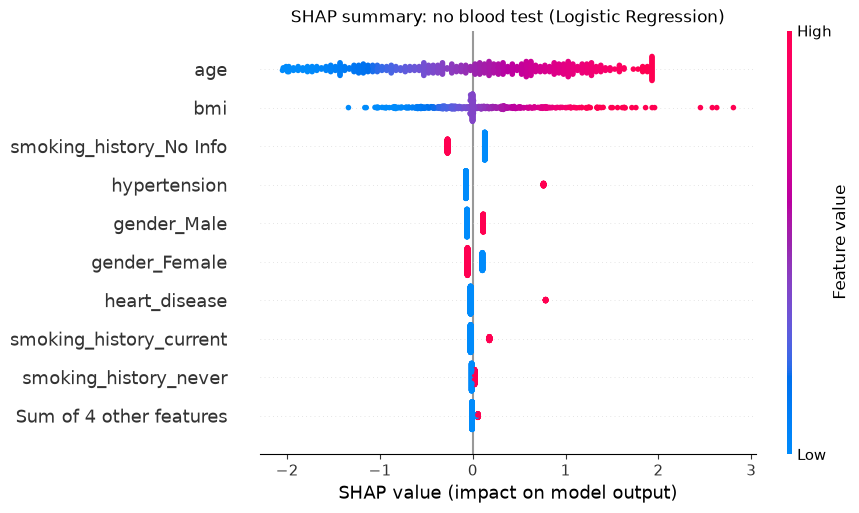

In [47]:
for set_name, values in shap_values.items():
    np.random.seed(RANDOM_STATE)   # beeswarm shuffles the dots randomly; fix it so the plot is the same each run
    shap.plots.beeswarm(values, show=False)
    plt.title("SHAP summary: " + set_name + " (" + best_name[set_name] + ")")
    plt.savefig("figures/kaggle/fig15_shap_beeswarm_" + set_name.replace(" ", "_") + ".png",
                dpi=150, bbox_inches="tight")
    plt.show()

**How to read it:** each dot is one patient. Position = how much that feature pushed the prediction up (right) or down (left). Colour = the feature's value (red = high, blue = low). For a Random Forest the values are in probability units; for Logistic Regression they are in log-odds.

**Observation:** **All features (Random Forest):** HbA1c and glucose have by far the largest impact. High values (red) push the probability up strongly (up to about +0.5) and low values push it down; age, BMI, hypertension and heart disease follow. **No blood test (Logistic Regression):** age has the widest spread (older = red = higher risk, up to about +2 in log-odds), followed by BMI (higher = more risk). Hypertension and heart disease add risk when present, and "No Info" smoking lowers it. All directions match the odds ratios.

## G.4 Do the methods agree?
Rank of each feature (1 = most important) for the **no blood test** model under each method. SHAP and odds ratios are per one-hot column, so for this table we add up a text column's one-hot parts.

In [48]:
def per_original_feature(series):
    # one-hot names like "smoking_history_never" -> "smoking_history"; "age" stays "age"
    original = [n if n in X_test.columns else n.rsplit("_", 1)[0] for n in series.index]
    return series.groupby(original).sum()

s = "no blood test"
agree = pd.DataFrame({
    "LR |log odds ratio|": per_original_feature(np.log(odds[s].dropna()).abs()),
    "Permutation": perm[s],
    "mean |SHAP|": per_original_feature(pd.Series(np.abs(shap_values[s].values).mean(axis=0),
                                                  index=shap_values[s].feature_names))}).dropna()
agree.rank(ascending=False).astype(int).sort_values("mean |SHAP|")

,LR |log odds ratio|,Permutation,mean |SHAP|
age,1,1,1
bmi,3,2,2
smoking_history,2,4,3
gender,4,6,4
hypertension,5,3,5
heart_disease,6,5,6


**Observation:** **All three methods rank age first** for the no-blood-test model, and BMI is 2nd (permutation, SHAP) or 3rd (LR coefficients). They disagree only about the order of the weaker features (smoking history, gender, hypertension, heart disease). Agreement between three different methods makes us confident that **age and BMI are the main non-lab risk signals** in this data.

## G.5 Explaining single patients (SHAP waterfall)

For the **no blood test** model we pick three patients from the SHAP sample using its screening threshold: a **caught diabetic** (highest probability), a **cleared healthy** patient (lowest probability) and a **missed diabetic** (the false negative with the lowest probability).
A waterfall starts at the base value $E[f(x)]$ (the average prediction) and adds each feature's SHAP value until it reaches this patient's prediction $f(x)$.
If the final model is Logistic Regression, $f(x)$ is in **log-odds**; the probability is $\sigma(f(x)) = \frac{1}{1+e^{-f(x)}}$ (shown in the table below).

In [49]:
s = "no blood test"
sample_idx = X_test.sample(500, random_state=RANDOM_STATE).index      # same sample as in explain()
proba = best_clf[s].predict_proba(X_test.loc[sample_idx])[:, 1]
actual = y_test.loc[sample_idx].values

tp = np.where((actual == 1) & (proba >= THRESHOLD[s]))[0]
tn = np.where((actual == 0) & (proba < THRESHOLD[s]))[0]
fn = np.where((actual == 1) & (proba < THRESHOLD[s]))[0]
print("In the sample: caught", len(tp), "| cleared", len(tn), "| missed", len(fn))

In the sample: caught 35 | cleared 319 | missed 9


In [50]:
patients = {}                                  # a group can be empty in the sample, so check each
if len(tp) > 0:
    patients["caught_diabetic"] = tp[np.argmax(proba[tp])]
if len(tn) > 0:
    patients["cleared_healthy"] = tn[np.argmin(proba[tn])]
if len(fn) > 0:
    patients["missed_diabetic"] = fn[np.argmin(proba[fn])]

chosen = X_test.loc[sample_idx].iloc[list(patients.values())].copy()
chosen.index = list(patients.keys())
chosen["probability"] = proba[list(patients.values())].round(3)
chosen

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,probability
caught_diabetic,Female,66.0,0,0,never,54.16,7.5,159,0.932
cleared_healthy,Female,2.0,0,0,No Info,15.10,4.0,159,0.011
missed_diabetic,Female,45.0,0,0,never,23.30,8.8,140,0.237


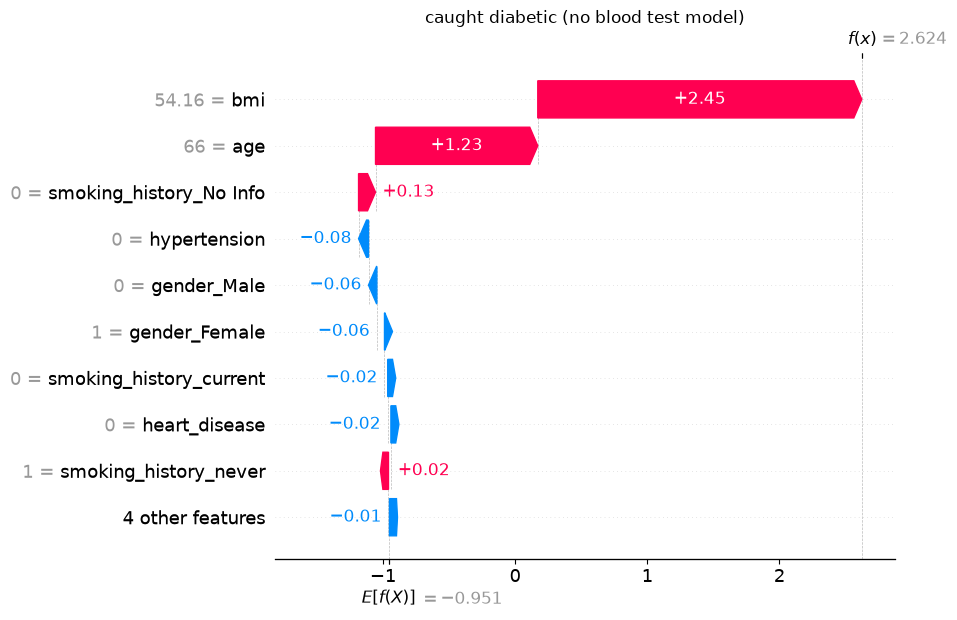

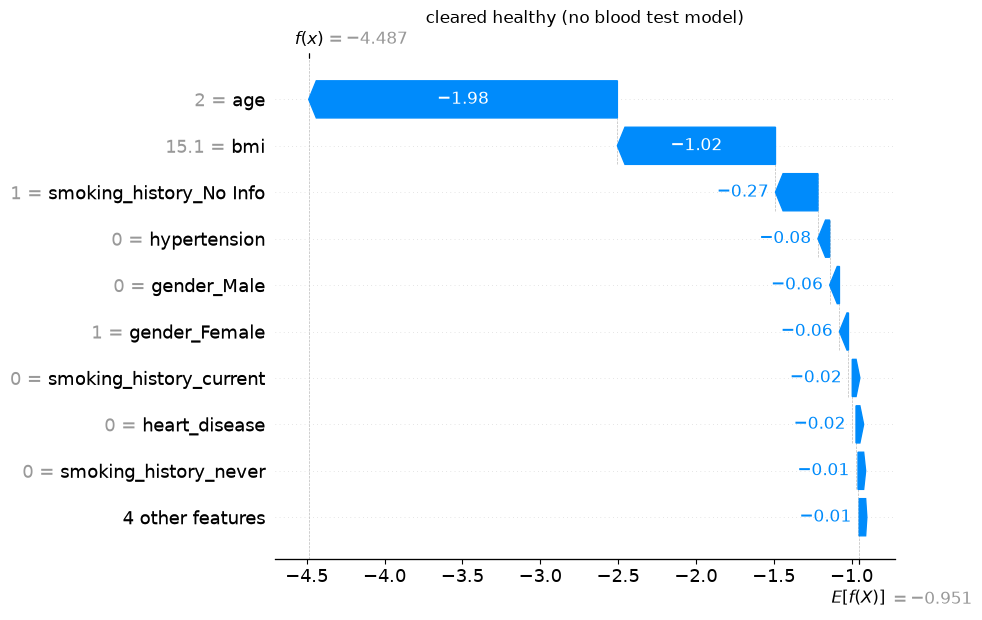

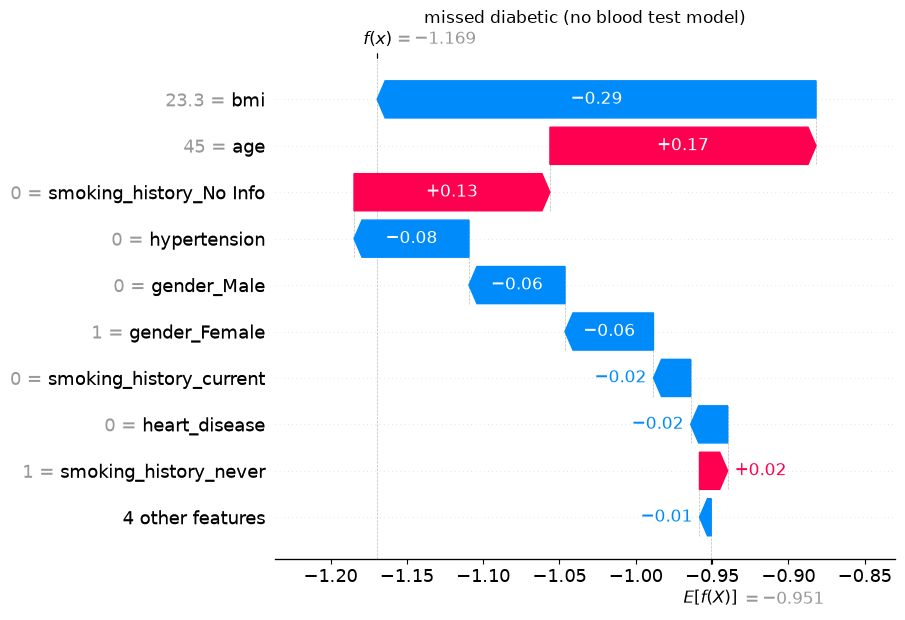

In [51]:
for label, row in patients.items():
    shap.plots.waterfall(shap_values[s][row], show=False)
    plt.title(label.replace("_", " ") + " (no blood test model)")
    plt.savefig("figures/kaggle/fig16_waterfall_" + label + ".png", dpi=150, bbox_inches="tight")
    plt.show()

**Observation:** In the 500-patient SHAP sample, the no-blood-test model (threshold 0.5) catches 35 diabetics, clears 319 healthy patients and misses 9.
- **Caught diabetic** (probability 0.932): a 66-year-old woman with a BMI of **54.16**. Her high age and very high BMI both push the risk far up.
- **Cleared healthy** (probability 0.011): a **2-year-old** with a BMI of 15.1. Young age and low BMI push the risk to almost 0.
- **Missed diabetic** (probability 0.237): a 45-year-old woman with a normal BMI of **23.3**, no hypertension, no heart disease and no smoking. Her normal BMI pulls the risk down more than her age pushes it up. Yet her **HbA1c is 8.8**, clearly diabetic on a blood test the screening model cannot see. Screening on risk factors alone will always miss some diabetics who look healthy; a positive screen should lead to a blood test, and so should other warning signs.

## G.6 Clinical sanity check

**What matches medical knowledge**
- **HbA1c and glucose** dominate the all-features model. This is expected and partly circular, because diabetes is diagnosed from these tests (B.6).
- **Age, BMI, hypertension and heart disease** raise risk in the no-blood-test model, matching the known risk factors from A.1. Age and BMI are the two strongest, as in medical guidelines for who should be tested.
- Being **male** slightly raises risk (odds ratio 1.19), which also matches the medical literature.

**What is surprising**
- **"No Info" smoking lowers the risk** (odds ratio 0.67). Missing smoking information does not protect anyone. "No Info" is common among **children**, who rarely have diabetes, so the category stands in for being young. It is a pattern in how the data was *recorded*, not a cause.
- **Former smokers** have the highest diabetes rate (about 17%, B.3). Former smokers are typically older, so age is probably behind this too.

**Caution:** odds ratios and SHAP show what the models learned from *this* data. They describe associations, not causes.

## G.7 Regression: what goes with a higher BMI?

Ridge is a linear model, so its coefficients (Section D.6) are its explanation: the change in predicted BMI for a 1-SD increase in each numeric feature (or for being in a category).

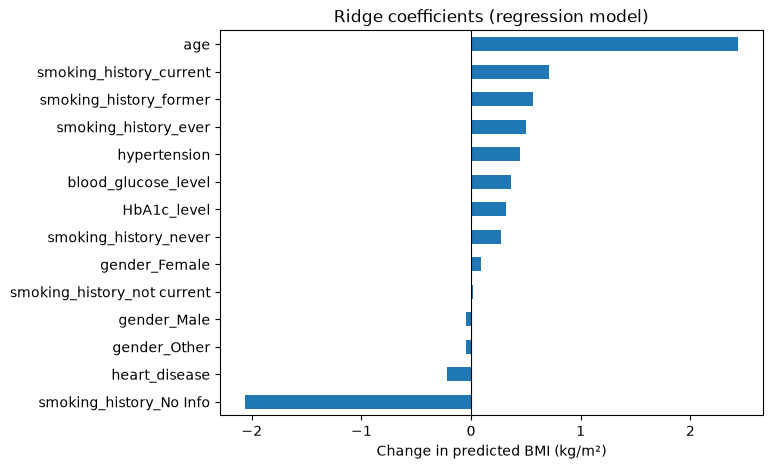

In [52]:
coefs.sort_values().plot(kind="barh", color="tab:blue", figsize=(7, 5))
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Change in predicted BMI (kg/m²)")
plt.title("Ridge coefficients (regression model)")
plt.savefig("figures/kaggle/fig17_ridge_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** For BMI, **age** is by far the strongest factor (+2.43 per SD), mostly because children have low BMIs, and **"No Info" smoking** (−2.06) again acts as a stand-in for being young. Hypertension, glucose and HbA1c go with a slightly higher BMI, consistent with obesity being linked to blood pressure and blood sugar. All these effects are small compared with how much BMI varies between people (R² 0.17).

# Section H: Conclusion *(Rubric 5)*

## H.1 Final models

In [53]:
rows = []
for set_name in feature_sets:
    rows.append(["Classification, " + set_name, best_name[set_name], THRESHOLD[set_name],
                 "recall %.3f, precision %.3f, ROC-AUC %.3f" % (
                     recall_score(y_test, y_screen[set_name]), precision_score(y_test, y_screen[set_name]),
                     roc_auc_score(y_test, test_proba[set_name]))])
rows.append(["Regression (BMI)", "Ridge " + str(ridge_grid.best_params_), "-",
             "R2 %.3f, RMSE %.2f, MAE %.2f" % (
                 r2_score(y_test_reg, y_pred_reg), root_mean_squared_error(y_test_reg, y_pred_reg),
                 mean_absolute_error(y_test_reg, y_pred_reg))])

final = pd.DataFrame(rows, columns=["task", "final model", "threshold", "test scores"])
final

,task,final model,threshold,test scores
0,"Classification, all features",Random Forest,0.7,"recall 0.784, precision 0.729, ROC-AUC 0.974"
1,"Classification, no blood test",Logistic Regression,0.5,"recall 0.787, precision 0.211, ROC-AUC 0.825"
2,Regression (BMI),Ridge {'model__alpha': 100},-,"R2 0.171, RMSE 7.04, MAE 5.30"


## H.2 Did we meet the success criteria from Section A.4?

In [54]:
rows = []
for set_name in feature_sets:
    rows.append([set_name, "test recall >= 0.75", recall_score(y_test, y_screen[set_name]), 0.75])
    rows.append([set_name, "test ROC-AUC >= 0.80", roc_auc_score(y_test, test_proba[set_name]), 0.80])
rows.append(["Ridge (BMI)", "beat mean baseline (R2)", r2_score(y_test_reg, y_pred_reg),
             r2_score(y_test_reg, baseline_pred)])

criteria = pd.DataFrame(rows, columns=["task", "criterion", "our result", "target"])
criteria["met?"] = criteria["our result"] >= criteria["target"]
criteria.round(3)

,task,criterion,our result,target,met?
0,all features,test recall >= 0.75,0.784,0.75,True
1,all features,test ROC-AUC >= 0.80,0.974,0.80,True
2,no blood test,test recall >= 0.75,0.787,0.75,True
3,no blood test,test ROC-AUC >= 0.80,0.825,0.80,True
4,Ridge (BMI),beat mean baseline (R2),0.171,-0.00,True


### Answers to the questions from Section A
**1. Did we meet the success criteria?** Yes, all five:
- **All features** (Random Forest, t = 0.7): recall 0.784, ROC-AUC 0.974. This is easy, because the label is largely defined by HbA1c and glucose.
- **No blood test** (Logistic Regression, t = 0.5): recall 0.787, ROC-AUC 0.825. This is the honest screening result, but precision is only 0.211: about 4 in 5 flagged patients are not diabetic, so it must be followed by a blood test.
- **Ridge on BMI**: R² 0.171, clearly above the baseline (−0.000), but BMI is only weakly predictable from these features.

**2. What drives diabetes risk, according to the models?**
- With blood tests: **HbA1c and glucose** (they define the diagnosis).
- Without blood tests: **age** and **BMI**, then hypertension, heart disease and being male. All three explanation methods agree on age and BMI.
- **BMI is the key modifiable factor**: the no-blood-test model raises the odds by 1.82 for every 1-SD increase.

**3. Why not HbA1c for regression?** In this dataset HbA1c follows the diagnosis (values above 6.6 occur only in diabetics) and cannot be predicted from routine features (R² 0.042). Using the diagnosis as an input would be leakage, so we used BMI instead.

**4. Compared with Pima:** the larger dataset gives much more stable results (CV std ≤ 0.01 vs 0.02–0.04), and tuning now gives real gains.

## H.3 Limitations and future work

**Limitations**
- **Unknown origin:** the Kaggle dataset does not document where or when the data was collected, so we cannot say which population it represents. Some patterns (HbA1c and glucose taking only a few values, the label following cut-offs) suggest it may be partly synthetic.
- **Circular label:** with HbA1c and glucose as inputs, the classifier mostly re-learns the diagnostic cut-offs.
- **Filled-in BMI:** 22.5% of BMI values were placeholders (27.32); we treated them as missing, but imputation still weakens BMI as a feature.
- **Children are included:** many "No Info" smoking entries and low BMIs come from children, which creates proxy effects ("No Info" lowers risk).
- **Correlation, not causation**, and **not for clinical use**: this is a course prototype.

**Future work**
- Add more models in the next reviews (e.g. KNN, Naive Bayes, Gradient Boosting) and compare them on the no-blood-test task.
- Analyse adults and children separately.
- Validate on a dataset with a documented, real clinical source.

## H.4 Saved figures
All figures of this notebook are saved in `figures/kaggle/` for the report and slides.

In [55]:
for name in sorted(os.listdir("figures/kaggle")):
    print(name)

fig01_class_balance.png
fig02_histograms.png
fig03_diabetes_rate_by_group.png
fig04_boxplots.png
fig05_correlation.png
fig06_lab_values_by_class.png
fig07_bmi_target.png
fig08_reg_test_plots.png
fig09_clf_test_cm_roc.png
fig10_clf_threshold.png
fig11_clf_cm_screening.png
fig12_model_comparison.png
fig13_roc_comparison.png
fig14_permutation_importance.png
fig15_shap_beeswarm_all_features.png
fig15_shap_beeswarm_no_blood_test.png
fig16_waterfall_caught_diabetic.png
fig16_waterfall_cleared_healthy.png
fig16_waterfall_missed_diabetic.png
fig17_ridge_coefficients.png
